# Telco Customer Churn  Full Advanced ML Pipeline

> **Objective:** Build an end-to-end machine learning pipeline to predict which telecom customers are likely to churn (cancel their subscription), enabling proactive retention strategies.
>
> **Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customers, 21 features
>
> **Structure:**
> 1. Setup & Data Loading
> 2. Data Cleaning & Quality
> 3. Feature Engineering
> 4. Advanced EDA
> 5. ML Preparation (Split, Scale, SMOTE)
> 6. Advanced Feature Selection
> 7. Modeling, Comparison & Prediction
> 8. Neural Network
> 9. Final Synthesis & Deployment-Ready Pipeline

##  PART 0  Setup, Imports & Environment

In [ ]:
# Install required packages (Colab-safe)
!pip install kagglehub imbalanced-learn xgboost lightgbm --quiet
print("✅ Dependencies installed")

✅ Dependencies installed


In [ ]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import os, time, warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, chi2_contingency

# ── sklearn: preprocessing ────────────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import (StandardScaler, LabelEncoder,
                                    PowerTransformer, PolynomialFeatures)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import (VarianceThreshold, SelectKBest,
                                        f_classif, chi2, RFE, SelectFromModel,
                                        mutual_info_classif)

# ── sklearn: models ───────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ── sklearn: metrics & pipeline ───────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, precision_recall_curve,
                              average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# ── Imbalanced learning ───────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from collections import Counter

# ── Boosting libraries ────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import joblib

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3d4166',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0b0',
    'ytick.color':      '#a0a0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3e',
    'grid.alpha':       0.4,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#ffffff',
    'font.family':      'DejaVu Sans',
})

# Custom color palette
CHURN_PALETTE   = {'No': '#2ecc71', 'Yes': '#e74c3c'}   # Green = Stay, Red = Churn
CHURN_COLORS    = ['#2ecc71', '#e74c3c']
GRADIENT_COLORS = ['#667eea', '#764ba2']
MODEL_COLORS    = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

print("✅ All imports successful — dark theme active")
print(f"   NumPy {np.__version__} | Pandas {pd.__version__} | XGBoost {xgb.__version__}")

✅ All imports successful — dark theme active
   NumPy 2.0.2 | Pandas 2.2.2 | XGBoost 3.2.0


In [ ]:
# Mount Google Drive and create project folders
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = '/content/drive/MyDrive/TelcoChurn_Pipeline'
    USE_COLAB = True
    print("✅ Running on Google Colab — Drive mounted")
except ImportError:
    PROJECT = './TelcoChurn_Pipeline'
    USE_COLAB = False
    print("ℹ️  Running locally")

for sub in ['graphs', 'outputs', 'models']:
    os.makedirs(f'{PROJECT}/{sub}', exist_ok=True)

print(f"📁 Project root: {PROJECT}")

Mounted at /content/drive
✅ Running on Google Colab — Drive mounted
📁 Project root: /content/drive/MyDrive/TelcoChurn_Pipeline


##  PART 1  Data Loading & Initial Exploration

In [ ]:
# ── Download dataset via KaggleHub ────────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download('blastchar/telco-customer-churn')
file_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

df_raw = pd.read_csv(file_path)
print(f"✅ Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
✅ Loaded 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ── Initial type corrections ──────────────────────────────────────────────────
df = df_raw.copy()

# Drop ID column — it has zero predictive value and introduces noise
df.drop('customerID', axis=1, inplace=True)

# TotalCharges is stored as string — new customers (tenure=0) have empty string
# We coerce those to NaN and handle them in the cleaning step
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Create binary target for modeling (keeps original 'Churn' for EDA)
df['Churn_binary'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(f"Shape after dropping customerID: {df.shape}")
print(f"TotalCharges NaN count: {df['TotalCharges'].isna().sum()}  (new customers with tenure=0)")

Shape after dropping customerID: (7043, 21)
TotalCharges NaN count: 11  (new customers with tenure=0)


In [ ]:
# ── Dataset dimensions and column types ──────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('=' * 55)
print(f'  DATASET OVERVIEW')
print('=' * 55)
print(f'  Rows            : {df.shape[0]:,}')
print(f'  Columns         : {df.shape[1]}')
print(f'  Numeric columns : {len(num_cols)}')
print(f'  String columns  : {len(cat_cols)}')
print('=' * 55)
print(f'  Numeric  : {num_cols}')
print(f'  Categoric: {cat_cols}')

  DATASET OVERVIEW
  Rows            : 7,043
  Columns         : 21
  Numeric columns : 5
  String columns  : 16
  Numeric  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
  Categoric: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


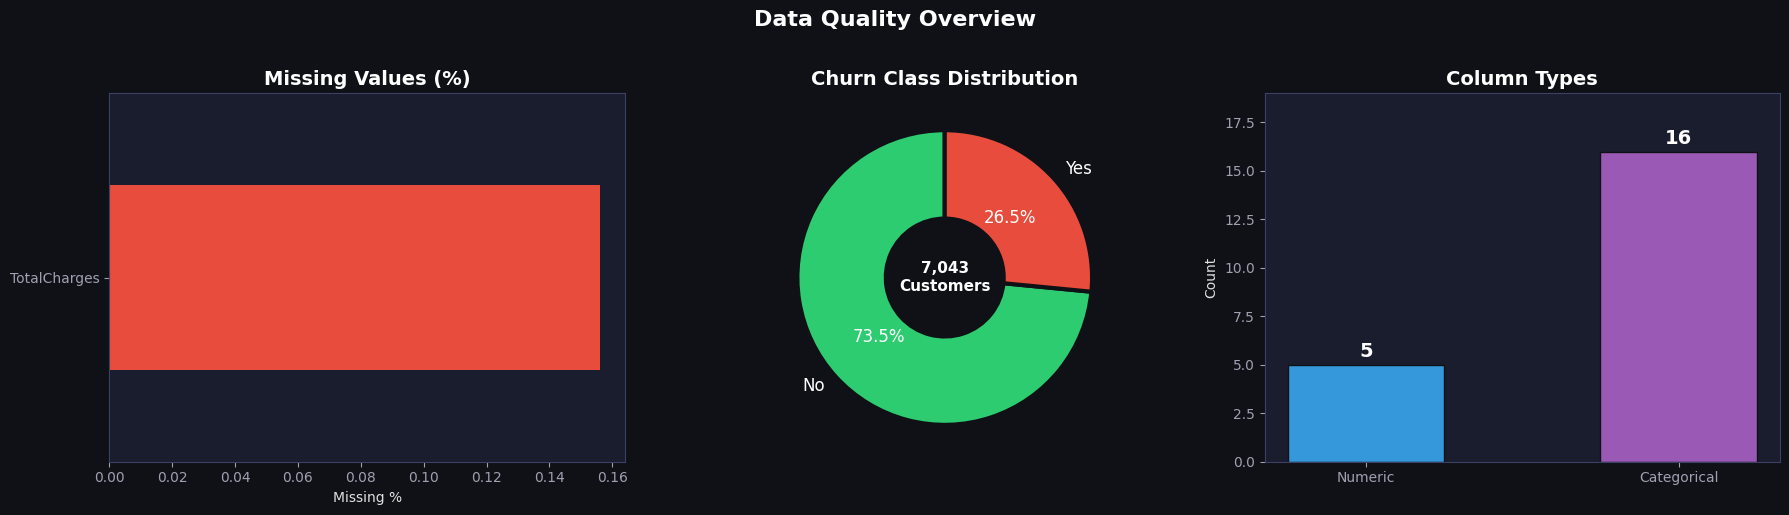


📊 Quality Summary
  Duplicates detected (after removing customerID): 22
  Missing values: 11 total  (0.16% max in one column)


In [ ]:
# ── Data Quality Dashboard ────────────────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = 100 * missing_count / len(df)
dups          = df.duplicated().sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Data Quality Overview', fontsize=16, fontweight='bold', color='white', y=1.02)

# -- Missing values bar --
ax = axes[0]
missing_nonzero = missing_pct[missing_pct > 0]
if len(missing_nonzero) == 0:
    ax.text(0.5, 0.5, 'No Missing\nValues Found!',
            ha='center', va='center', fontsize=18, color='#2ecc71',
            transform=ax.transAxes, fontweight='bold')
else:
    missing_nonzero.plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('Missing Values (%)')
ax.set_xlabel('Missing %')

# -- Churn distribution donut --
ax = axes[1]
churn_counts = df['Churn'].value_counts()
wedges, texts, autotexts = ax.pie(
    churn_counts, labels=churn_counts.index,
    colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
    wedgeprops={'width': 0.6, 'edgecolor': '#0f1117', 'linewidth': 3},
    startangle=90
)
for t in texts + autotexts:
    t.set_color('white')
    t.set_fontsize(12)
ax.set_title('Churn Class Distribution')
ax.text(0, 0, f'{len(df):,}\nCustomers', ha='center', va='center',
        fontsize=11, color='white', fontweight='bold')

# -- Column type breakdown --
ax = axes[2]
type_counts = pd.Series({'Numeric': len(num_cols), 'Categorical': len(cat_cols)})
bars = ax.bar(type_counts.index, type_counts.values,
              color=['#3498db', '#9b59b6'], width=0.5, edgecolor='#0f1117')
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontsize=14,
            color='white', fontweight='bold')
ax.set_title('Column Types')
ax.set_ylabel('Count')
ax.set_ylim(0, max(type_counts.values) + 3)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/00_quality_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

print(f"\n📊 Quality Summary")
print(f"  Duplicates detected (after removing customerID): {dups}")
print(f"  Missing values: {missing_count.sum()} total  ({missing_pct.max():.2f}% max in one column)")

In [ ]:
# ── Descriptive Statistics for continuous variables ───────────────────────────
continuous = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_table = df[continuous].describe().T
stats_table['skewness']  = df[continuous].skew()
stats_table['kurtosis']  = df[continuous].kurtosis()
stats_table['median']    = df[continuous].median()
print("Descriptive Statistics — Continuous Variables")
display(stats_table[['count','mean','median','std','min','max','skewness','kurtosis']].round(3))

# ── Class comparative analysis ────────────────────────────────────────────────
class_means = df.groupby('Churn')[continuous].mean()
diff        = abs(class_means.loc['No'] - class_means.loc['Yes'])
rel_diff    = (diff / df[continuous].mean()) * 100

print("\n📊 Class Comparison (Non-Churner vs Churner)")
comparison = pd.DataFrame({
    'Non-Churner': class_means.loc['No'],
    'Churner':     class_means.loc['Yes'],
    'Abs Diff':    diff,
    'Rel Diff (%)': rel_diff
}).round(2)
display(comparison)

print("\n🔍 Key Insight: Churners have ~60% shorter tenure but pay ~20% more per month")

Descriptive Statistics — Continuous Variables


,count,mean,median,std,min,max,skewness,kurtosis
tenure,7043.0,32.371,29.000,24.559,0.00,72.00,0.240,-1.387
MonthlyCharges,7043.0,64.762,70.350,30.090,18.25,118.75,-0.221,-1.257
TotalCharges,7032.0,2283.300,1397.475,2266.771,18.80,8684.80,0.962,-0.232



📊 Class Comparison (Non-Churner vs Churner)


,Non-Churner,Churner,Abs Diff,Rel Diff (%)
tenure,37.57,17.98,19.59,60.52
MonthlyCharges,61.27,74.44,13.18,20.35
TotalCharges,2555.34,1531.80,1023.55,44.83



🔍 Key Insight: Churners have ~60% shorter tenure but pay ~20% more per month


##  PART 2 Data Cleaning

In [ ]:
# ── Step 1: Work on a clean copy ──────────────────────────────────────────────
df_clean = df.copy()

# ── Step 2: Fix redundant categories ──────────────────────────────────────────
# 'No internet service' and 'No phone service' mean the same as 'No'
# in their respective dependent columns — collapsing avoids artificial distinction
internet_deps = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies']
for col in internet_deps:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')
print(f"✅ Harmonised 7 columns — all now binary (Yes / No)")

# ── Step 3: Impute TotalCharges with median ────────────────────────────────────
# Median preferred over mean because TotalCharges is right-skewed (skewness ≈ 0.96)
tc_median = df_clean['TotalCharges'].median()
df_clean['TotalCharges'].fillna(tc_median, inplace=True)
print(f"✅ Imputed {df['TotalCharges'].isna().sum()} missing TotalCharges with median={tc_median:.0f}")

# ── Step 4: Remove duplicates ─────────────────────────────────────────────────
n_before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"✅ Removed {n_before - len(df_clean)} duplicate rows → {len(df_clean):,} remain")

# ── Step 5: Outlier check (IQR) ────────────────────────────────────────────────
print("\n📐 IQR Outlier Scan:")
for col in continuous:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:20s}: {n_out} outliers  (Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f})")

print("\n  → No outliers removed: extreme values represent valid heavy-users or long-tenure clients.")
print(f"\n✅ Clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

✅ Harmonised 7 columns — all now binary (Yes / No)
✅ Imputed 11 missing TotalCharges with median=1397
✅ Removed 22 duplicate rows → 7,021 remain

📐 IQR Outlier Scan:
  tenure              : 0 outliers  (Q1=9.0, Q3=55.0, IQR=46.0)
  MonthlyCharges      : 0 outliers  (Q1=35.8, Q3=89.9, IQR=54.2)
  TotalCharges        : 0 outliers  (Q1=411.1, Q3=3801.7, IQR=3390.5)

  → No outliers removed: extreme values represent valid heavy-users or long-tenure clients.

✅ Clean dataset: 7,021 rows × 21 columns


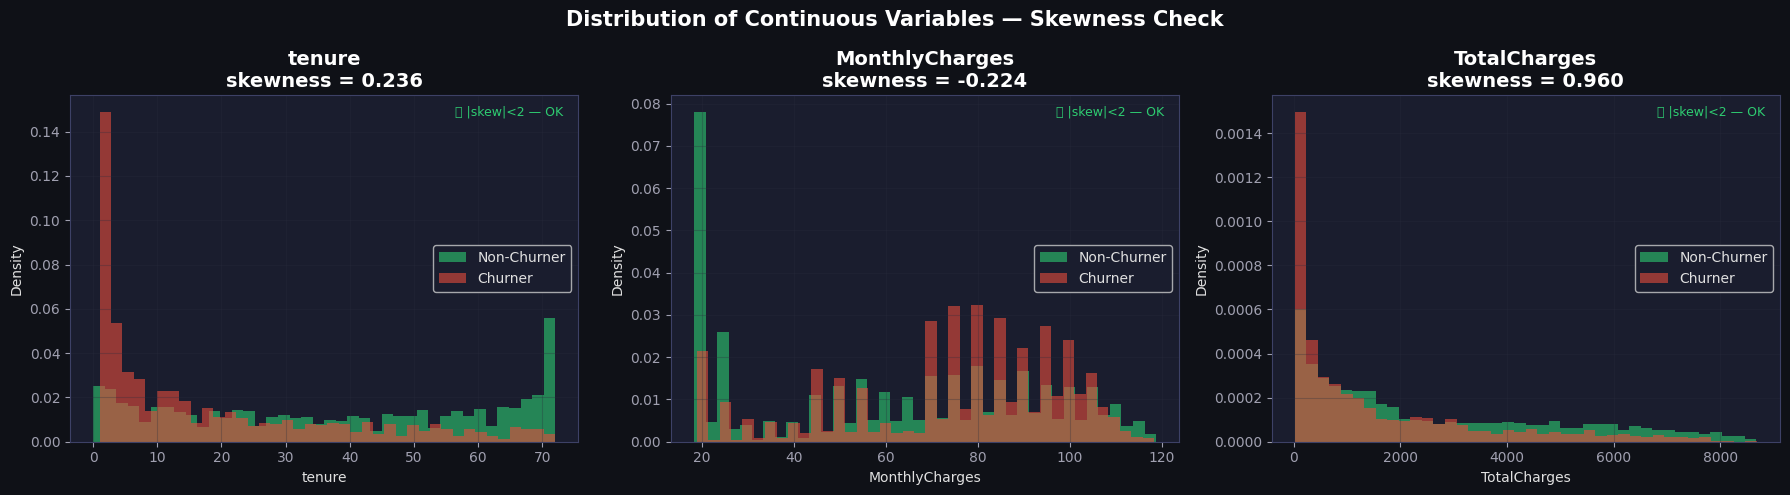

→ None of the 3 base variables exceed |skewness|=2. No log transform applied yet.
  (ContractRisk & MonthlyToTotalRatio will be created & transformed in Feature Engineering)


In [ ]:
# ── Skewness assessment before transformation ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Continuous Variables — Skewness Check', fontsize=15,
             color='white', fontweight='bold')

for ax, col in zip(axes, continuous):
    skew_val = df_clean[col].skew()
    # Overlay histograms by churn class
    for churn_val, color, label in [('No','#2ecc71','Non-Churner'), ('Yes','#e74c3c','Churner')]:
        subset = df_clean[df_clean['Churn'] == churn_val][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f'{col}\nskewness = {skew_val:.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    # Threshold annotation
    threshold_note = '⚠️ |skew|>2 → log needed' if abs(skew_val) > 2 else '✅ |skew|<2 — OK'
    ax.text(0.97, 0.97, threshold_note, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            color='#e74c3c' if abs(skew_val) > 2 else '#2ecc71')

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/01_skewness_check.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

# Skewness is checked only on original variables — engineered ones (ContractRisk etc.)
# will be evaluated in Part 3
print("→ None of the 3 base variables exceed |skewness|=2. No log transform applied yet.")
print("  (ContractRisk & MonthlyToTotalRatio will be created & transformed in Feature Engineering)")

##  PART 3  Feature Engineering

In [ ]:
# ── Feature Engineering — creating 8 informative derived variables ────────────
# Each feature is designed to capture a specific business signal

fe = df_clean.copy()

# 1. AvgMonthlyCharges — historical average monthly charge
#    Measures baseline willingness to pay over the customer's lifetime
fe['AvgMonthlyCharges'] = fe['TotalCharges'] / (fe['tenure'] + 1)

# 2. ChargeTrend — current bill vs historical average
#    Positive = customer is paying more now → potential dissatisfaction
fe['ChargeTrend'] = fe['MonthlyCharges'] - fe['AvgMonthlyCharges']

# 3. ContractRisk — monthly charge per month of tenure
#    High for new customers with expensive plans → prime churn candidates
fe['ContractRisk'] = fe['MonthlyCharges'] / (fe['tenure'] + 1)

# 4. MonthlyToTotalRatio — how much of total spend is from the current month
#    High ratio = very new customer (little history) with high monthly bill
fe['MonthlyToTotalRatio'] = fe['MonthlyCharges'] / (fe['TotalCharges'] + 1)

# 5. NumActiveServices — count of all subscribed services
#    High engagement = lower churn; single service = highest risk
service_cols = ['PhoneService','MultipleLines','InternetService',
                'OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
for col in service_cols:
    fe[col + '_bin'] = (fe[col].isin(['Yes', 'Fiber optic', 'DSL'])).astype(int)
fe['NumActiveServices'] = fe[[c + '_bin' for c in service_cols]].sum(axis=1)
fe.drop(columns=[c + '_bin' for c in service_cols], inplace=True)

# 6. AvgServiceUsage — normalised service engagement rate
fe['AvgServiceUsage'] = fe['NumActiveServices'] / 9.0

# 7 & 8. Log transforms for highly skewed engineered variables
#         ContractRisk skewness ≈ 2.7 → needs log1p
#         MonthlyToTotalRatio skewness ≈ 2.4 → needs log1p
fe['ContractRisk_log']       = np.log1p(fe['ContractRisk'])
fe['MonthlyToTotalRatio_log'] = np.log1p(fe['MonthlyToTotalRatio'])

print(f"✅ Feature Engineering complete")
print(f"   Before: {df_clean.shape[1]} columns")
print(f"   After : {fe.shape[1]} columns  (+{fe.shape[1] - df_clean.shape[1]} new features)")

# Verify skewness improvement
skew_check = pd.DataFrame({
    'Variable': ['ContractRisk','ContractRisk_log','MonthlyToTotalRatio','MonthlyToTotalRatio_log'],
    'Skewness': [fe['ContractRisk'].skew(), fe['ContractRisk_log'].skew(),
                 fe['MonthlyToTotalRatio'].skew(), fe['MonthlyToTotalRatio_log'].skew()]
}).set_index('Variable').round(3)
skew_check['Log Needed?'] = skew_check['Skewness'].abs().apply(lambda x: '⚠️ Yes' if x > 2 else '✅ No')
print("\n📐 Skewness Verification:")
display(skew_check)

✅ Feature Engineering complete
   Before: 21 columns
   After : 29 columns  (+8 new features)

📐 Skewness Verification:


,Skewness,Log Needed?
Variable,,
ContractRisk,2.718,⚠️ Yes
ContractRisk_log,0.985,✅ No
MonthlyToTotalRatio,2.375,⚠️ Yes
MonthlyToTotalRatio_log,2.175,⚠️ Yes


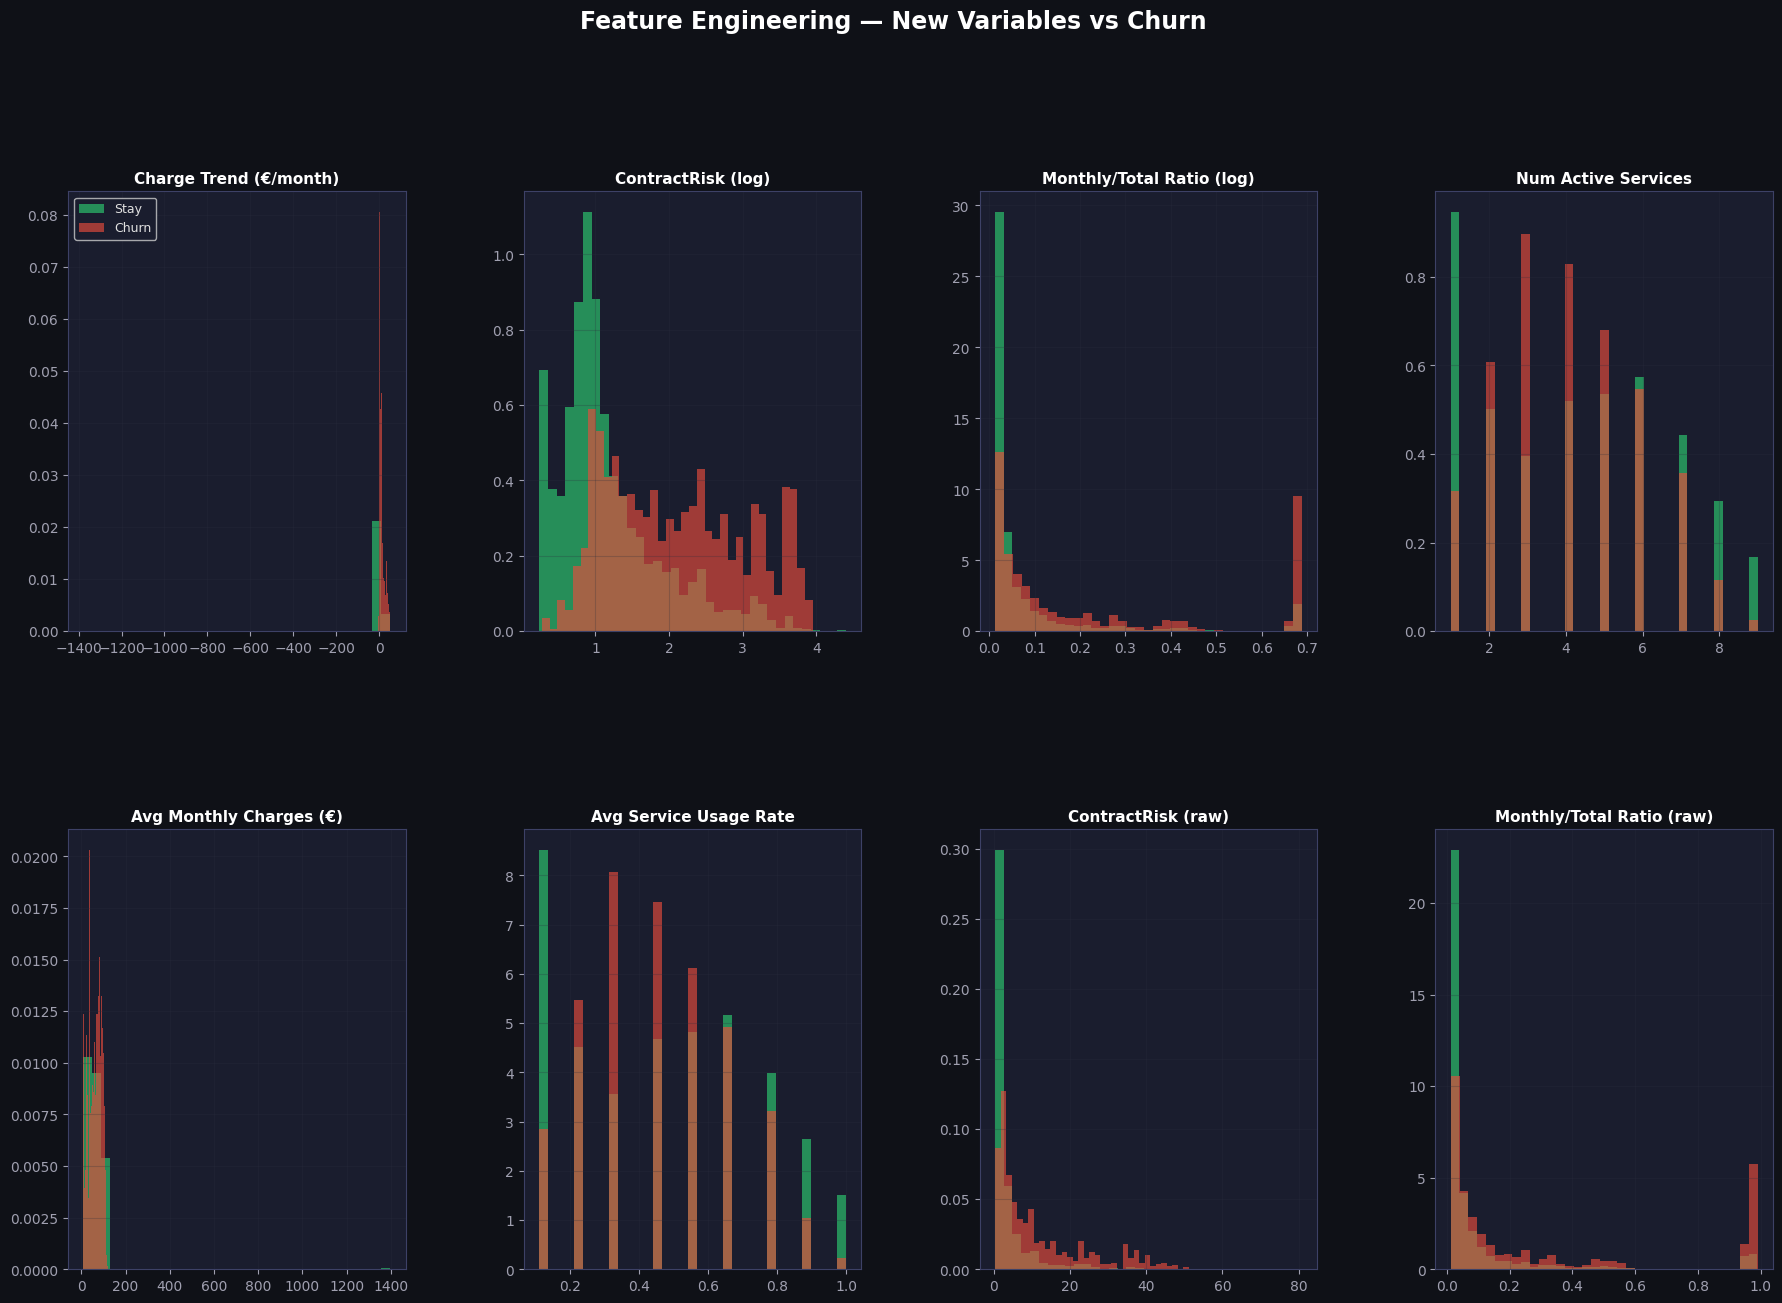

🔍 ContractRisk_log shows the cleanest separation between Churn / Stay classes


In [ ]:
# ── Feature Engineering Visualisation ────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Feature Engineering — New Variables vs Churn', fontsize=17,
             color='white', fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

fe_features = [
    ('ChargeTrend',           'Charge Trend (€/month)'),
    ('ContractRisk_log',      'ContractRisk (log)'),
    ('MonthlyToTotalRatio_log','Monthly/Total Ratio (log)'),
    ('NumActiveServices',     'Num Active Services'),
    ('AvgMonthlyCharges',     'Avg Monthly Charges (€)'),
    ('AvgServiceUsage',       'Avg Service Usage Rate'),
    ('ContractRisk',          'ContractRisk (raw)'),
    ('MonthlyToTotalRatio',   'Monthly/Total Ratio (raw)'),
]

for idx, (feat, title) in enumerate(fe_features):
    r, c = divmod(idx, 4)
    ax = fig.add_subplot(gs[r, c])

    for churn_val, color, label in [('No','#2ecc71','Stay'), ('Yes','#e74c3c','Churn')]:
        vals = fe[fe['Churn'] == churn_val][feat].dropna()
        ax.hist(vals, bins=35, alpha=0.65, color=color, label=label, density=True)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.25)
    if idx == 0:
        ax.legend(fontsize=9)

plt.savefig(f'{PROJECT}/graphs/02_feature_engineering.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("🔍 ContractRisk_log shows the cleanest separation between Churn / Stay classes")

##  PART 4  Advanced Exploratory Data Analysis (EDA)

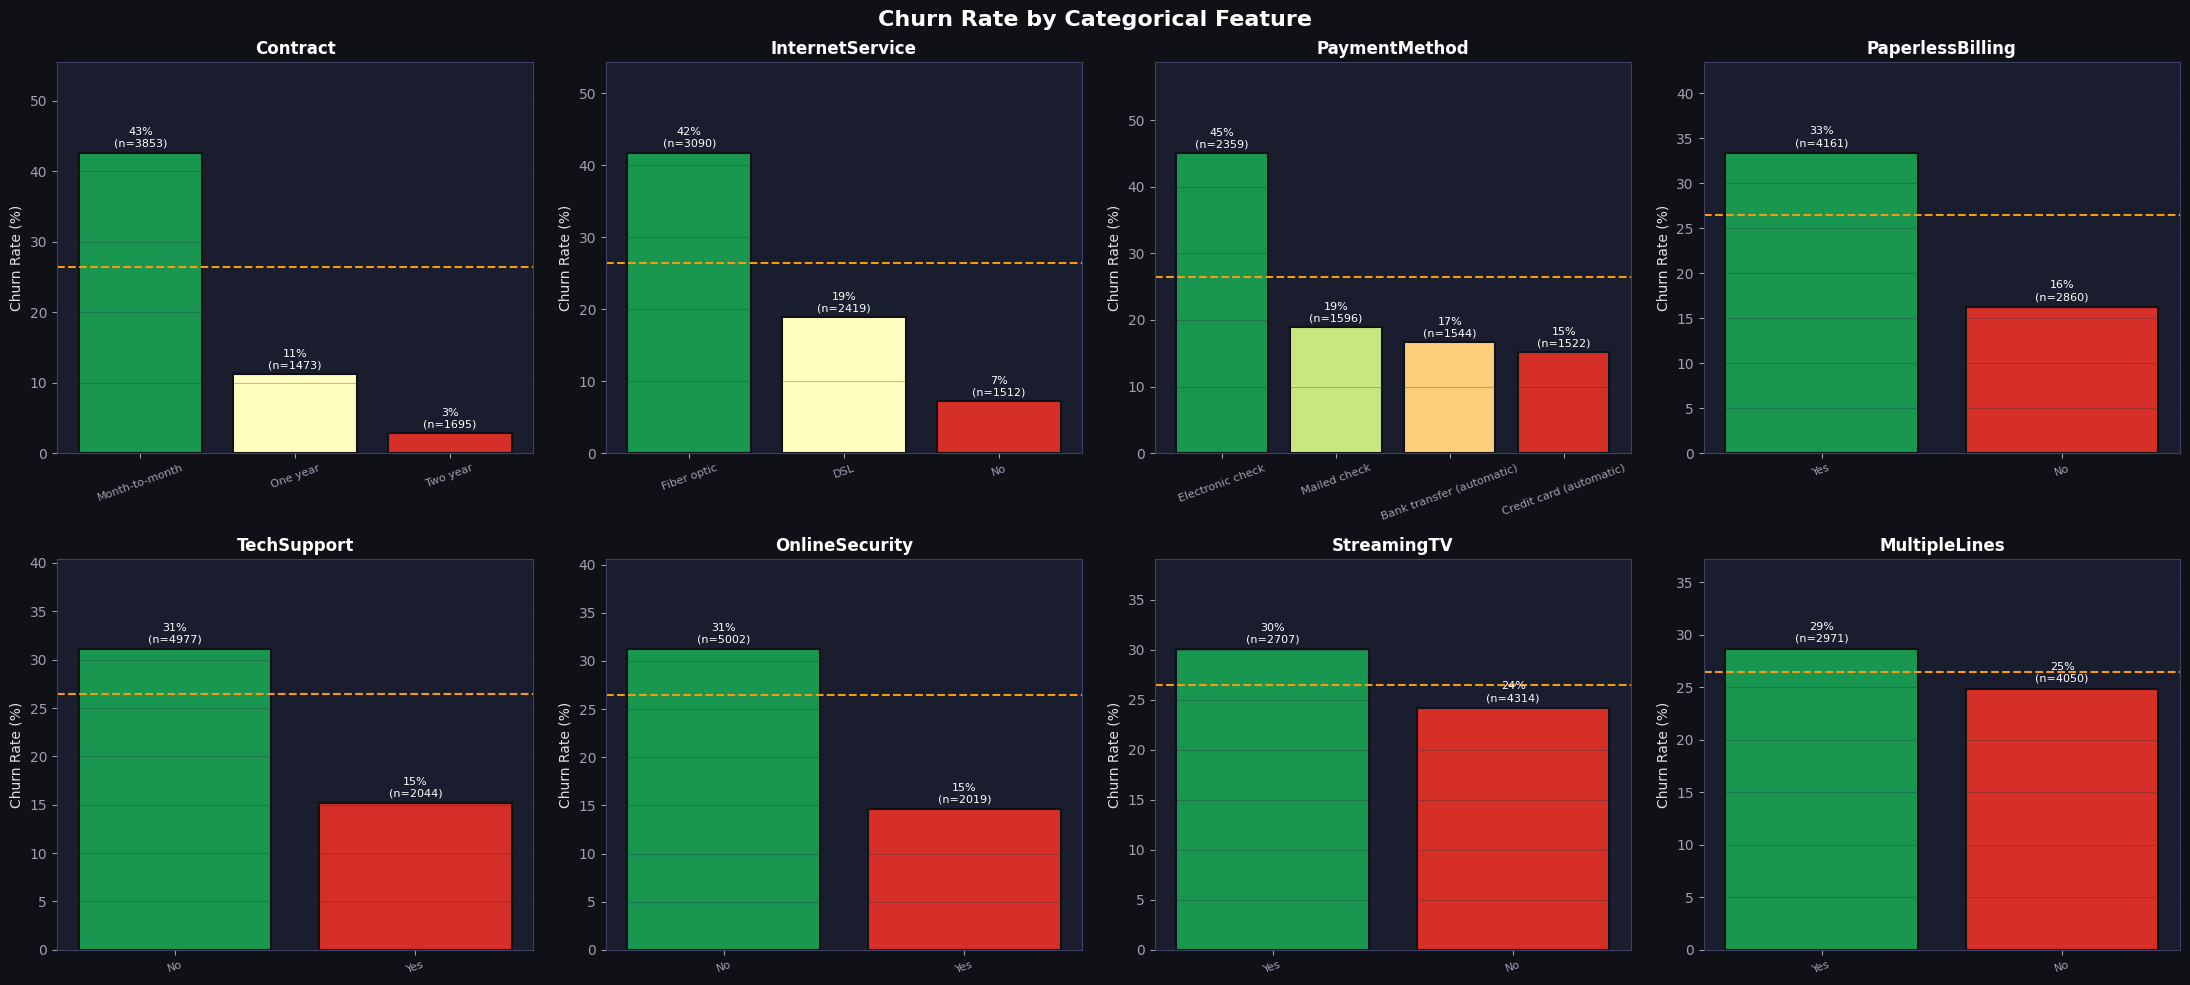

🔶 Orange dashed line = overall churn rate | Higher bar = higher risk


In [ ]:
# ── Categorical features vs Churn rate ────────────────────────────────────────
cat_features = ['Contract','InternetService','PaymentMethod',
                'PaperlessBilling','TechSupport','OnlineSecurity',
                'StreamingTV','MultipleLines']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Churn Rate by Categorical Feature', fontsize=16,
             color='white', fontweight='bold')
axes = axes.flatten()

for ax, feat in zip(axes, cat_features):
    churn_rate = fe.groupby(feat)['Churn_binary'].mean().sort_values(ascending=False)
    count_map  = fe[feat].value_counts()
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(churn_rate)))
    bars = ax.bar(churn_rate.index, churn_rate.values * 100, color=colors,
                  edgecolor='#0f1117', linewidth=1.5)
    for bar, (cat, rate) in zip(bars, churn_rate.items()):
        n = count_map[cat]
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{rate*100:.0f}%\n(n={n})',
                ha='center', va='bottom', fontsize=8, color='white')
    ax.set_title(feat, fontsize=12)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 130)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(fe['Churn_binary'].mean() * 100, color='#f39c12',
               linestyle='--', linewidth=1.5, label='Overall avg')

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/03_categorical_churn_rates.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("🔶 Orange dashed line = overall churn rate | Higher bar = higher risk")

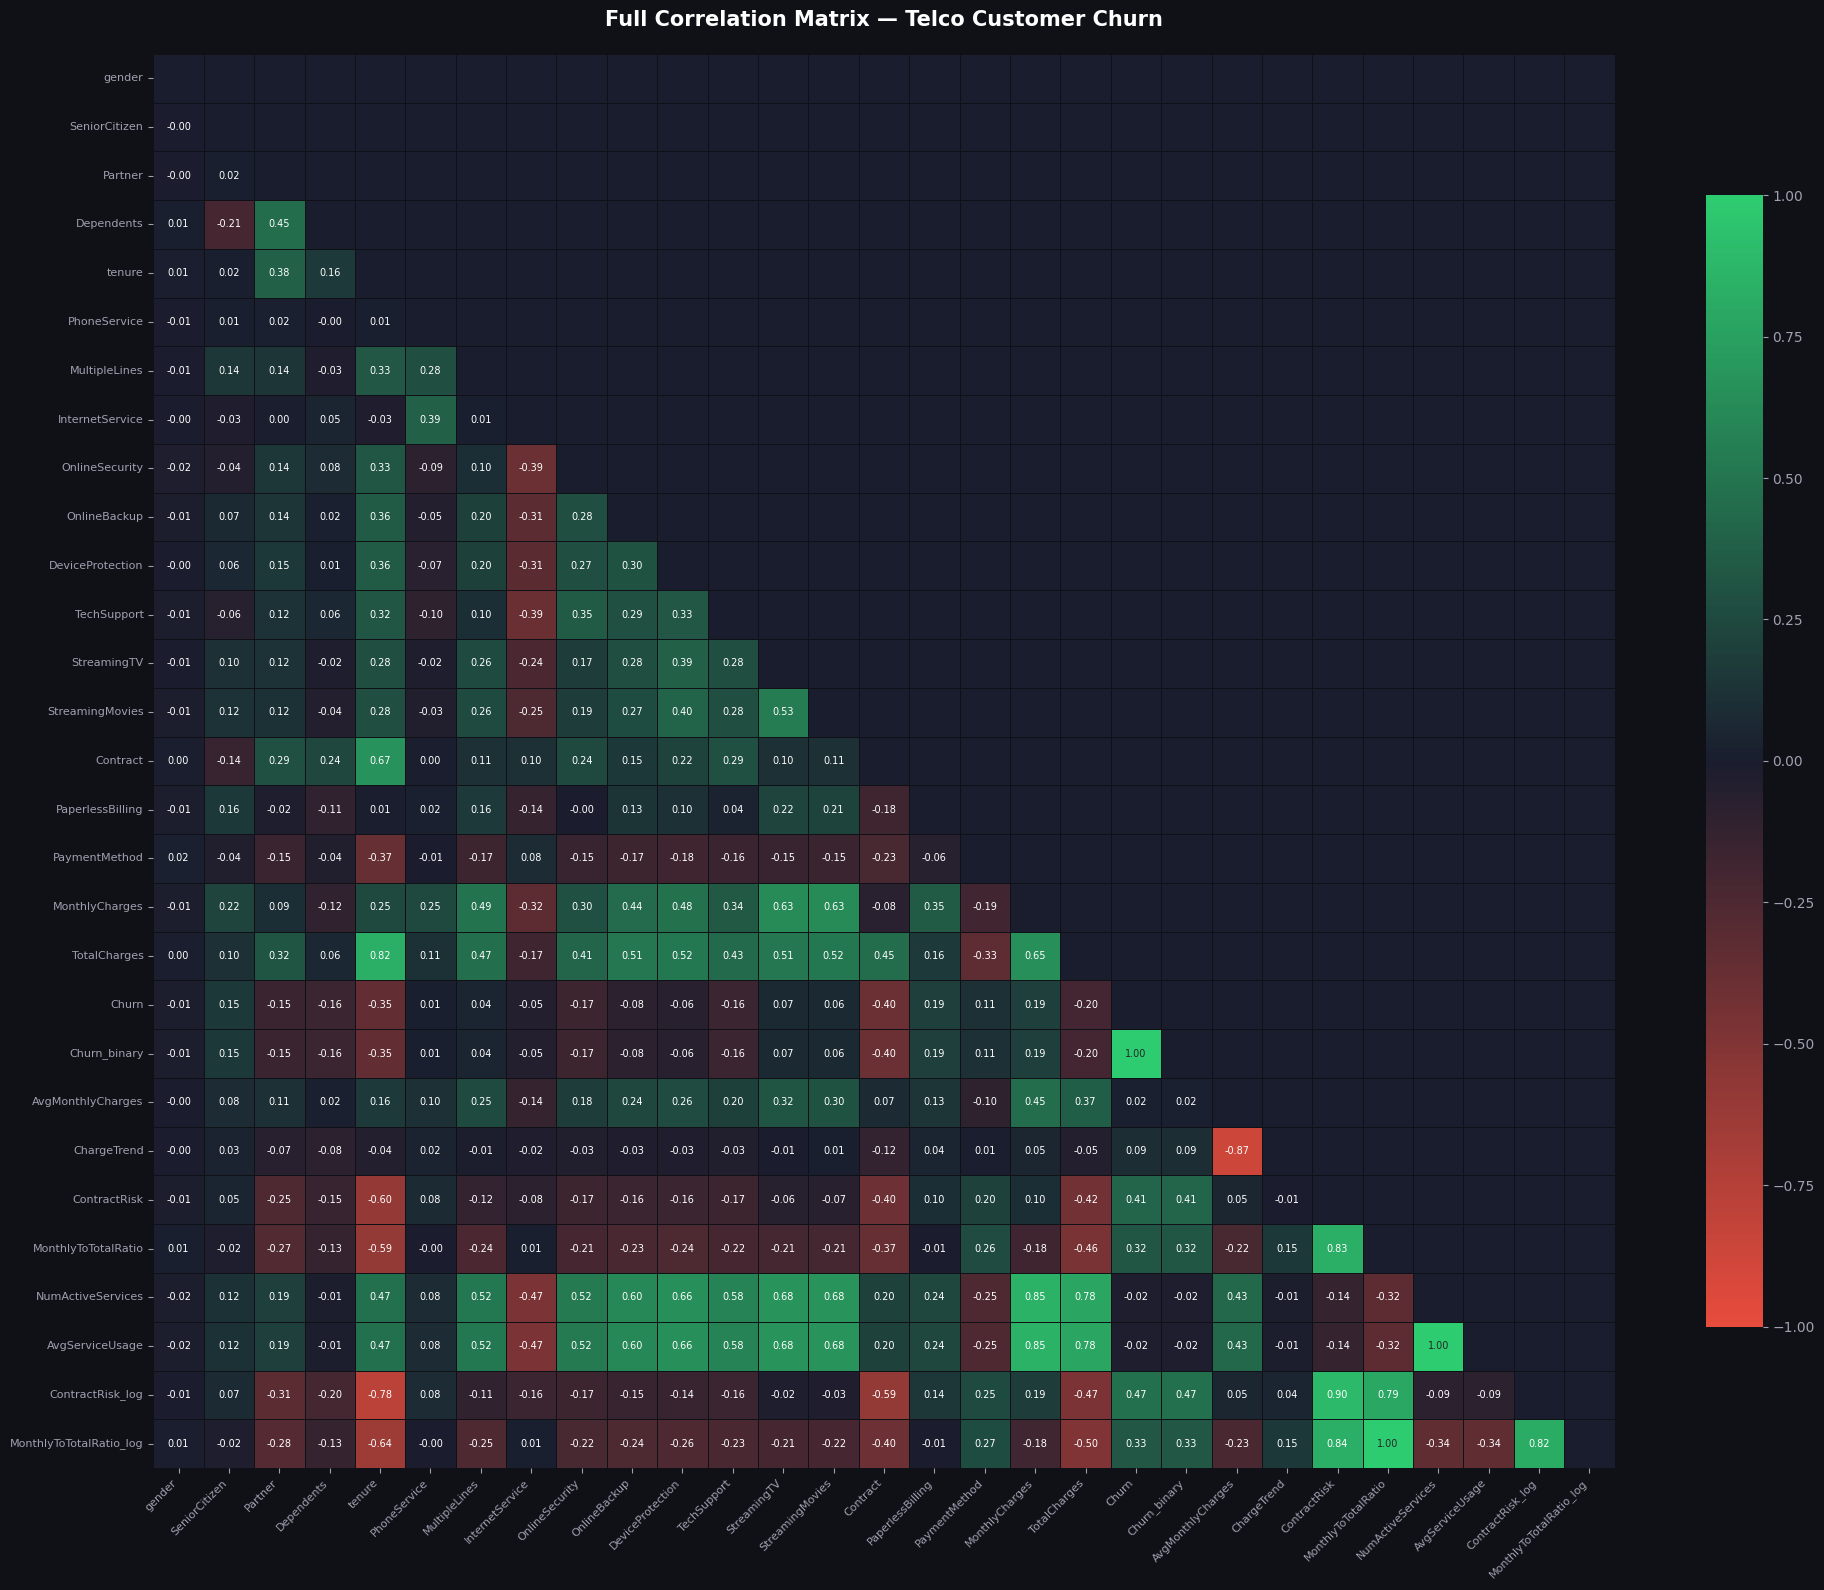

⚠️  High correlation pairs (|r| > 0.7) — multicollinearity risk:


,Var1,Var2,r
6,Churn,Churn_binary,1.000
13,NumActiveServices,AvgServiceUsage,1.000
12,MonthlyToTotalRatio,MonthlyToTotalRatio_log,0.997
9,ContractRisk,ContractRisk_log,0.898
7,AvgMonthlyCharges,ChargeTrend,-0.871
3,MonthlyCharges,AvgServiceUsage,0.851
2,MonthlyCharges,NumActiveServices,0.851
10,ContractRisk,MonthlyToTotalRatio_log,0.836
8,ContractRisk,MonthlyToTotalRatio,0.826
0,tenure,TotalCharges,0.825


In [ ]:
# ── Correlation heatmap (all features encoded) ────────────────────────────────
fe_encoded = fe.copy()
le_dict = {}
for col in fe_encoded.select_dtypes(include='object').columns:
    le_dict[col] = LabelEncoder()
    fe_encoded[col] = le_dict[col].fit_transform(fe_encoded[col].astype(str))

# Focus on relevant columns (drop binary-encoded service cols if any)
numeric_fe_cols = fe_encoded.select_dtypes(include=np.number).columns.tolist()
corr_matrix = fe_encoded[numeric_fe_cols].corr()

# Triangular mask for cleaner heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
fig.patch.set_facecolor('#0f1117')

# Custom diverging colormap
cmap = LinearSegmentedColormap.from_list(
    'churn_div', ['#e74c3c','#1a1d2e','#2ecc71'], N=256
)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, linecolor='#0f1117',
            cbar_kws={'shrink': 0.8}, ax=ax,
            vmin=-1, vmax=1)

ax.set_facecolor('#1a1d2e')
ax.set_title('Full Correlation Matrix — Telco Customer Churn',
             fontsize=15, fontweight='bold', color='white', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/04_correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

# High-correlation pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({'Var1': corr_matrix.columns[i],
                               'Var2': corr_matrix.columns[j],
                               'r': round(r, 3)})
print("⚠️  High correlation pairs (|r| > 0.7) — multicollinearity risk:")
display(pd.DataFrame(high_corr).sort_values('r', ascending=False, key=abs))

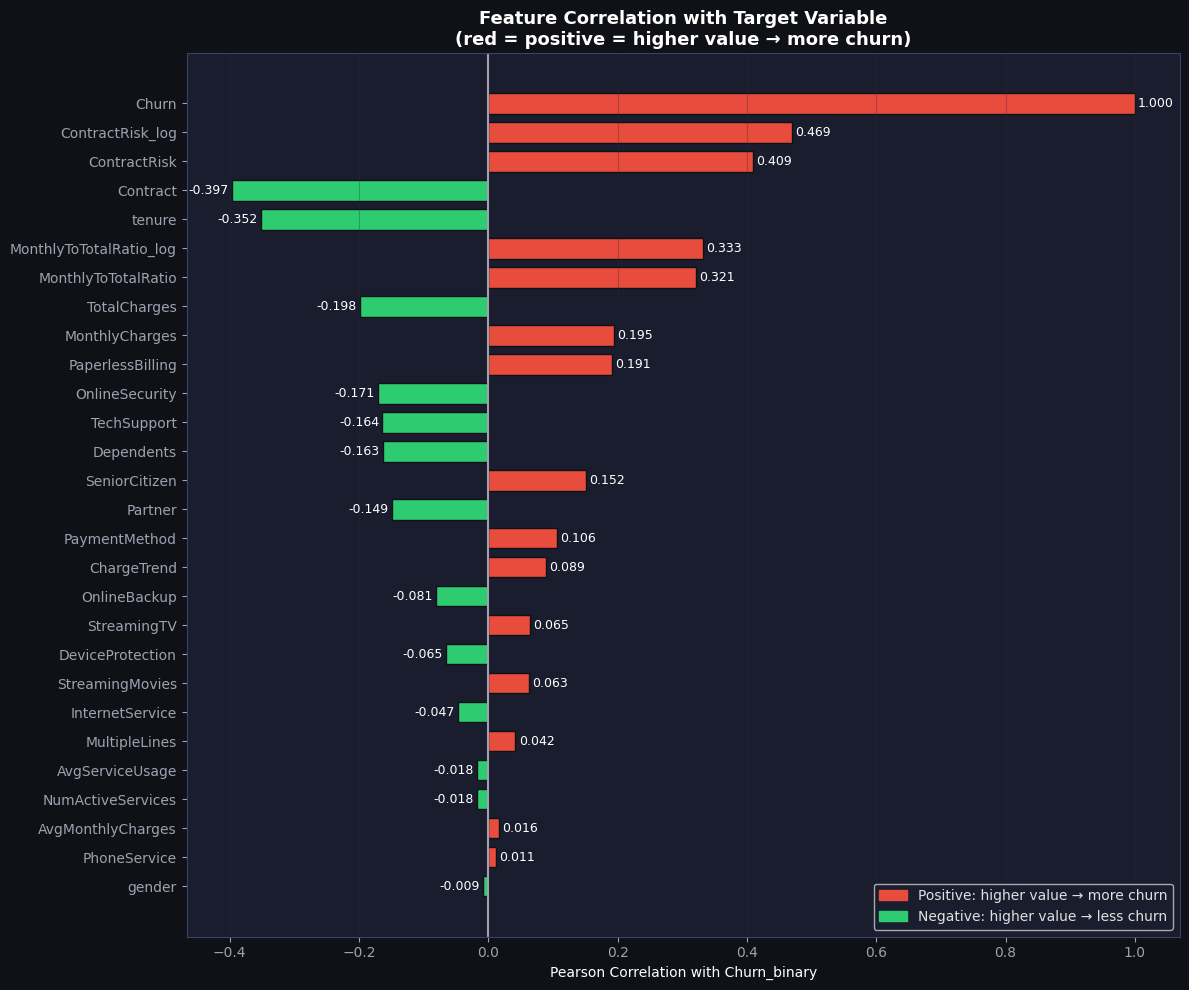


🏆 Top 5 predictors of churn:
  Churn                         : r = +1.000  (↑ more churn)
  ContractRisk_log              : r = +0.469  (↑ more churn)
  ContractRisk                  : r = +0.409  (↑ more churn)
  Contract                      : r = -0.397  (↓ less churn)
  tenure                        : r = -0.352  (↓ less churn)


In [ ]:
# ── Correlations with target variable ────────────────────────────────────────
target_corr = fe_encoded[numeric_fe_cols].corrwith(
    fe_encoded['Churn_binary']
).drop('Churn_binary').sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#0f1117')

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors,
               edgecolor='#0f1117', height=0.7)

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right',
            color='white', fontsize=9)

ax.axvline(0, color='#a0a0b0', linewidth=1.5)
ax.set_xlabel('Pearson Correlation with Churn_binary', color='white')
ax.set_title('Feature Correlation with Target Variable\n(red = positive = higher value → more churn)',
             fontsize=13, fontweight='bold', color='white')

red_patch   = mpatches.Patch(color='#e74c3c', label='Positive: higher value → more churn')
green_patch = mpatches.Patch(color='#2ecc71', label='Negative: higher value → less churn')
ax.legend(handles=[red_patch, green_patch], loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/05_target_correlations.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

top5 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(5)
print("\n🏆 Top 5 predictors of churn:")
for feat, val in top5.items():
    direction = '↑ more churn' if val > 0 else '↓ less churn'
    print(f"  {feat:30s}: r = {val:+.3f}  ({direction})")

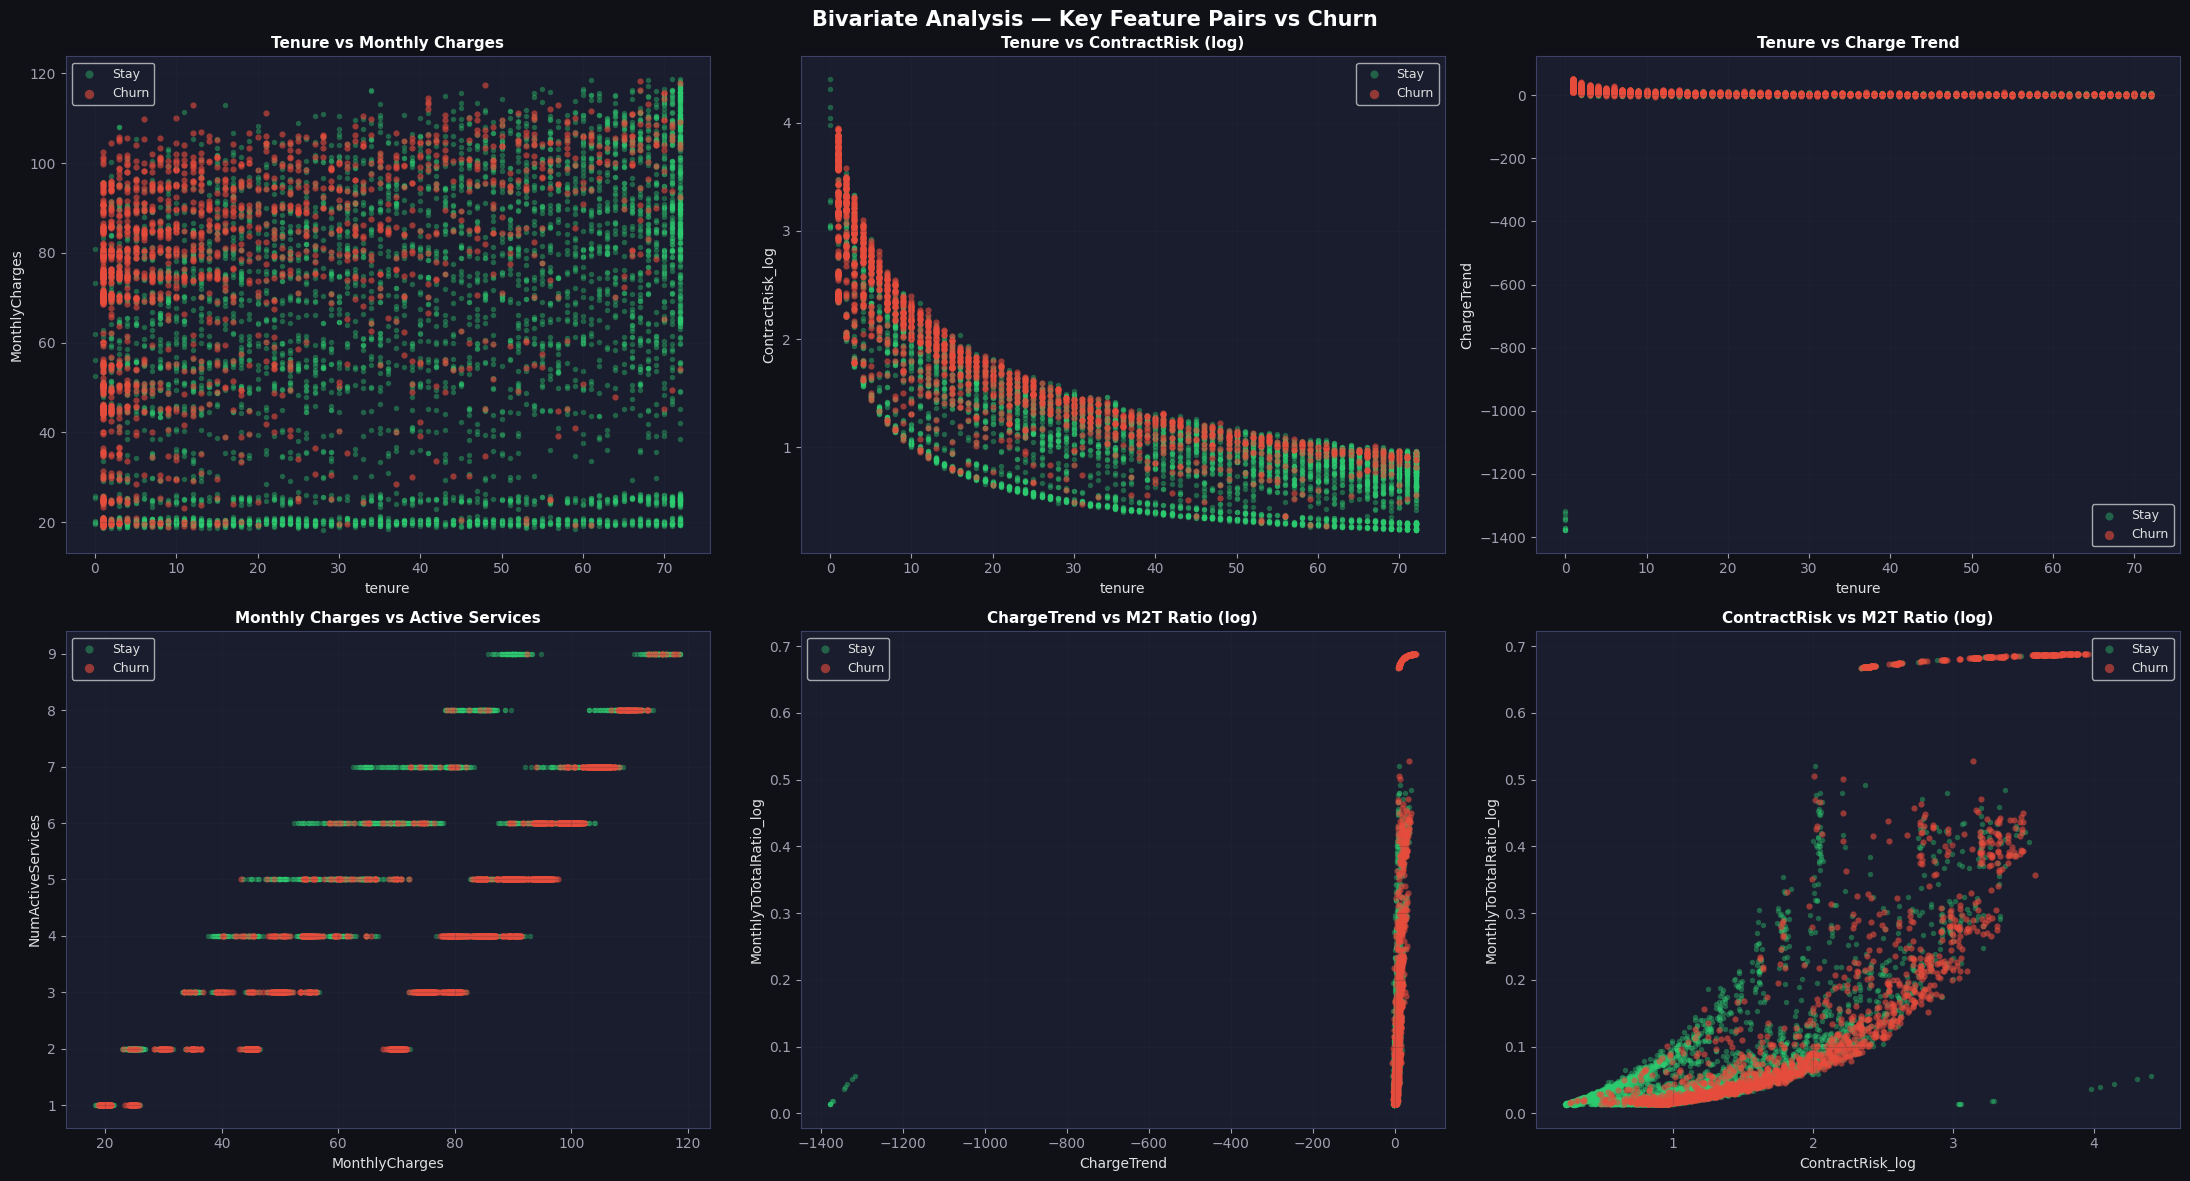

🔍 Top-left of tenure vs MonthlyCharges = churn hotspot (new + expensive)


In [ ]:
# ── Bivariate Scatter Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Bivariate Analysis — Key Feature Pairs vs Churn',
             fontsize=15, color='white', fontweight='bold')
axes = axes.flatten()

pairs = [
    ('tenure', 'MonthlyCharges',    'Tenure vs Monthly Charges'),
    ('tenure', 'ContractRisk_log',  'Tenure vs ContractRisk (log)'),
    ('tenure', 'ChargeTrend',       'Tenure vs Charge Trend'),
    ('MonthlyCharges', 'NumActiveServices', 'Monthly Charges vs Active Services'),
    ('ChargeTrend', 'MonthlyToTotalRatio_log', 'ChargeTrend vs M2T Ratio (log)'),
    ('ContractRisk_log', 'MonthlyToTotalRatio_log', 'ContractRisk vs M2T Ratio (log)'),
]

for ax, (xf, yf, title) in zip(axes, pairs):
    for churn_val, color, label, alpha, size in [
        ('No',  '#2ecc71', 'Stay',  0.4, 15),
        ('Yes', '#e74c3c', 'Churn', 0.6, 20)
    ]:
        mask = fe['Churn'] == churn_val
        ax.scatter(fe.loc[mask, xf], fe.loc[mask, yf],
                   c=color, alpha=alpha, s=size, label=label, linewidths=0)
    ax.set_xlabel(xf)
    ax.set_ylabel(yf)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, markerscale=1.5)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/06_bivariate_scatter.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("🔍 Top-left of tenure vs MonthlyCharges = churn hotspot (new + expensive)")

##  PART 5  ML Preparation (Encoding, Split, Scale, SMOTE)

In [ ]:
# ── Feature selection criteria: ───────────────────────────────────────────────
#   • |r| ≥ 0.05 with Churn_binary  (removes gender, PhoneService)
#   • No multicollinearity: avoid |r| > 0.9 between features (drop AvgServiceUsage)
#   • Include ≥ 3 engineered features
#   • Drop original skewed vars if log version included (ContractRisk, MonthlyToTotalRatio)

SELECTED_FEATURES = [
    'tenure', 'MonthlyCharges', 'Contract', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'PaymentMethod',
    'ChargeTrend', 'ContractRisk_log', 'MonthlyToTotalRatio_log',
    'NumActiveServices'
]
TARGET = 'Churn_binary'

# ── Encode categorical features ───────────────────────────────────────────────
fe_ml = fe[SELECTED_FEATURES + [TARGET]].copy()

encoders = {}
cat_feats = fe_ml.select_dtypes(include='object').columns.tolist()
for col in cat_feats:
    enc = LabelEncoder()
    fe_ml[col] = enc.fit_transform(fe_ml[col].astype(str))
    encoders[col] = enc
print(f"✅ Encoded {len(cat_feats)} categorical columns: {cat_feats}")

X = fe_ml[SELECTED_FEATURES]
y = fe_ml[TARGET]

print(f"\nFeature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}  |  Churn rate: {y.mean()*100:.1f}%")

✅ Encoded 6 categorical columns: ['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'PaymentMethod']

Feature matrix X: (7021, 12)
Target vector  y: (7021,)  |  Churn rate: 26.4%


Train: 5,616 rows  |  Test: 1,405 rows
Churn in train: 26.4%  |  Churn in test: 26.5%

Scaling check → mean: -0.000000  std: 1.000089

Before SMOTE: Counter({0: 4131, 1: 1485})
After  SMOTE: Counter({1: 4131, 0: 4131})


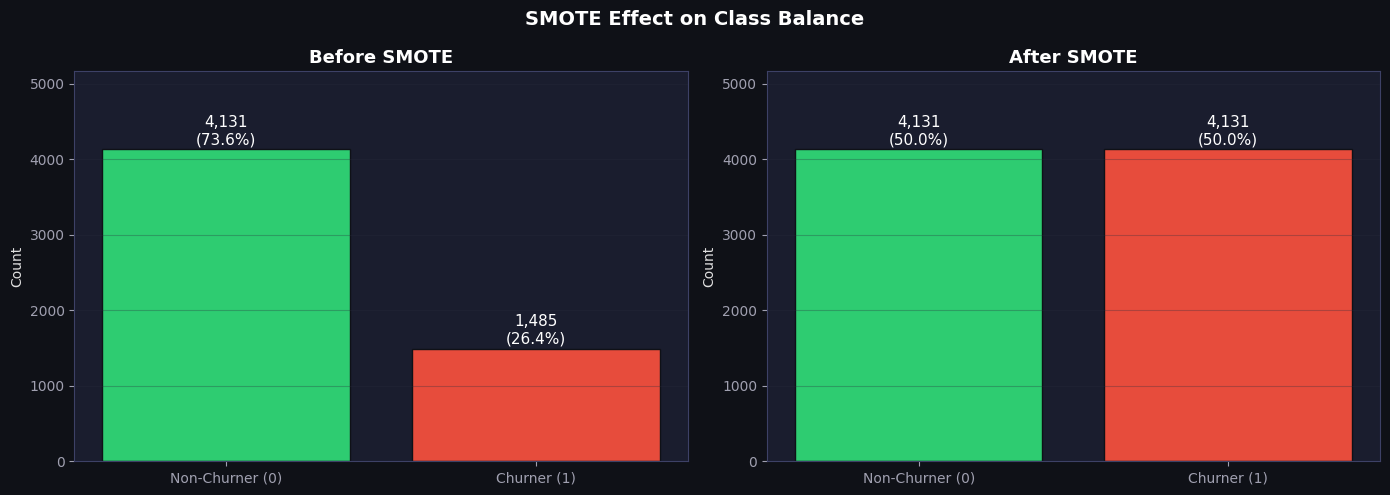

In [ ]:
# ── Stratified Train / Test Split ────────────────────────────────────────────
# stratify=y ensures equal churn proportion in both sets (critical for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Churn in train: {y_train.mean()*100:.1f}%  |  Churn in test: {y_test.mean()*100:.1f}%")

# ── StandardScaler (fit ONLY on train — prevents data leakage) ───────────────
# Fitting on test would leak test statistics into the normalisation step
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                           columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),
                           columns=X_test.columns, index=X_test.index)

print(f"\nScaling check → mean: {X_train_sc.mean().mean():.6f}  std: {X_train_sc.std().mean():.6f}")

# ── SMOTE — oversample minority class (apply ONLY on train set) ───────────────
# SMOTE generates synthetic churner examples by interpolating between real ones
# NEVER apply on test — that would artificially inflate test metrics
print(f"\nBefore SMOTE: {Counter(y_train)}")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f"After  SMOTE: {Counter(y_train_sm)}")

# ── Visualise SMOTE effect ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('SMOTE Effect on Class Balance', fontsize=14, color='white', fontweight='bold')

for ax, counts, label in zip(
    axes,
    [Counter(y_train), Counter(y_train_sm)],
    ['Before SMOTE', 'After SMOTE']
):
    bars = ax.bar(['Non-Churner (0)','Churner (1)'],
                  [counts[0], counts[1]],
                  color=['#2ecc71','#e74c3c'], edgecolor='#0f1117')
    for bar, val in zip(bars, [counts[0], counts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}\n({val/sum(counts.values())*100:.1f}%)',
                ha='center', va='bottom', color='white', fontsize=11)
    ax.set_title(label, fontsize=13)
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts.values()) * 1.25)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/07_smote_balance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

##  PART 6 Advanced Feature Selection (Filter | Wrapper | Embedded)

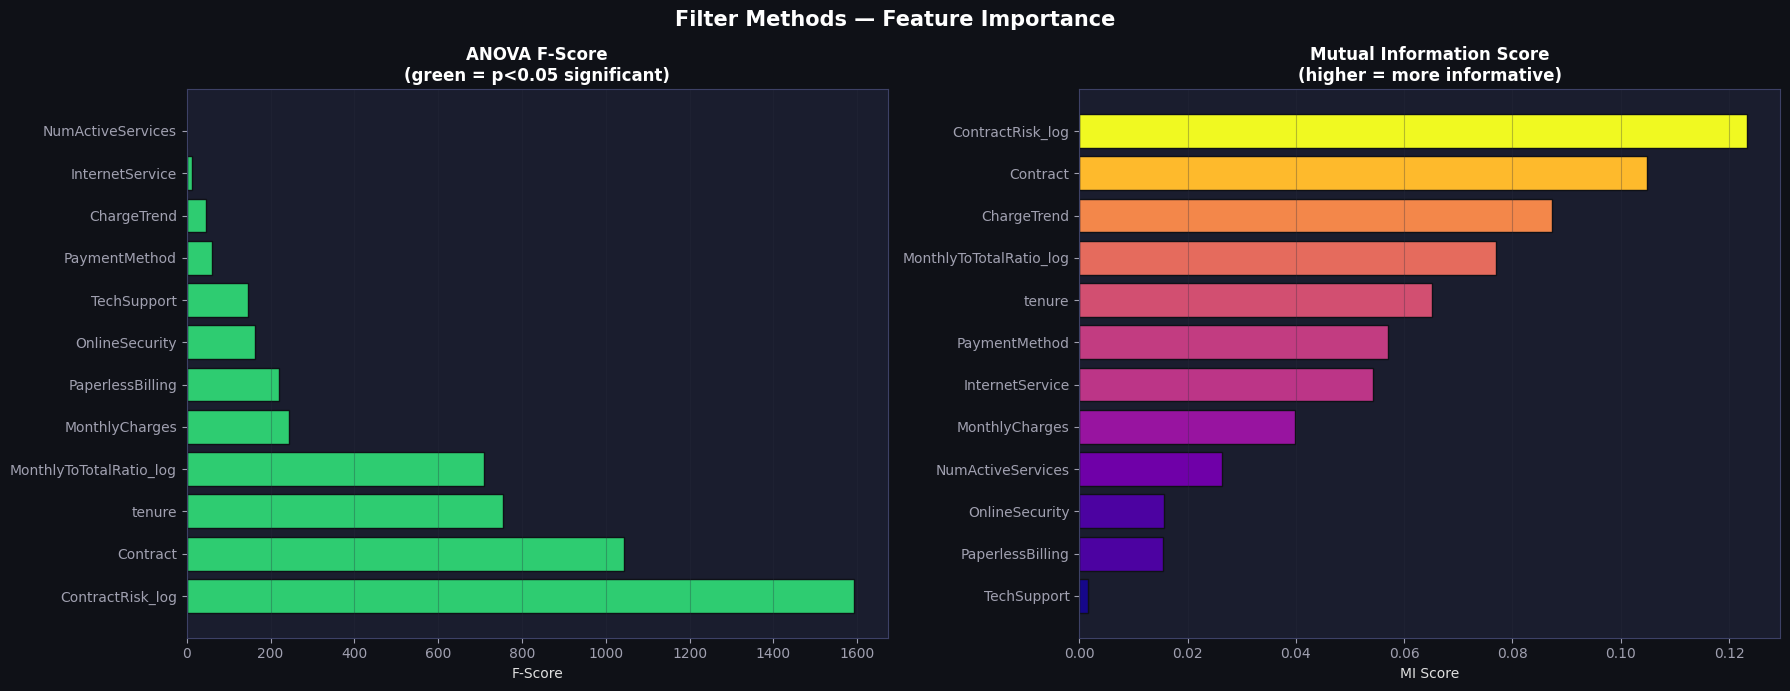

,Feature,F_Score,p_value,MI_Score,Pearson_r,Retained
9,ContractRisk_log,1592.7733,0.0000,0.1232,0.4690,True
2,Contract,1043.1633,0.0000,0.1049,-0.3965,True
0,tenure,755.7759,0.0000,0.0651,-0.3515,True
10,MonthlyToTotalRatio_log,708.5352,0.0000,0.0769,0.3326,True
1,MonthlyCharges,244.2177,0.0000,0.0399,0.1945,True
6,PaperlessBilling,219.0497,0.0000,0.0156,0.1909,True
4,OnlineSecurity,161.8509,0.0000,0.0157,-0.1705,True
5,TechSupport,146.3024,0.0000,0.0016,-0.1639,True
7,PaymentMethod,60.8415,0.0000,0.0570,0.1062,True
8,ChargeTrend,45.5975,0.0000,0.0874,0.0893,True


In [ ]:
# ── Method 1: Filter — ANOVA F-score & Mutual Information ────────────────────
# ANOVA F-score: measures between-class variance vs within-class variance
# Mutual Information: measures non-linear dependence between feature and target

f_scores, f_pvals = f_classif(X_train_sc, y_train)
mi_scores         = mutual_info_classif(X_train_sc, y_train, random_state=42)

filter_df = pd.DataFrame({
    'Feature':   SELECTED_FEATURES,
    'F_Score':   f_scores,
    'p_value':   f_pvals,
    'MI_Score':  mi_scores,
    'Pearson_r': [fe_ml[f].corr(fe_ml[TARGET]) for f in SELECTED_FEATURES],
}).sort_values('F_Score', ascending=False)

filter_df['Retained'] = filter_df['p_value'] < 0.05

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Filter Methods — Feature Importance', fontsize=15,
             color='white', fontweight='bold')

# F-scores
ax = axes[0]
colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in filter_df['p_value']]
bars = ax.barh(filter_df['Feature'], filter_df['F_Score'],
               color=colors, edgecolor='#0f1117')
ax.set_title('ANOVA F-Score\n(green = p<0.05 significant)', fontsize=12)
ax.set_xlabel('F-Score')
ax.grid(axis='x', alpha=0.3)

# Mutual Information
mi_sorted = filter_df.sort_values('MI_Score', ascending=True)
ax = axes[1]
cmap_vals = mi_sorted['MI_Score'] / mi_sorted['MI_Score'].max()
colors2   = plt.cm.plasma(cmap_vals)
ax.barh(mi_sorted['Feature'], mi_sorted['MI_Score'],
        color=colors2, edgecolor='#0f1117')
ax.set_title('Mutual Information Score\n(higher = more informative)', fontsize=12)
ax.set_xlabel('MI Score')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/08_filter_methods.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

display(filter_df.round(4))

Running RFE — this may take ~60 seconds...
  n= 5 → F1=0.7939 | ['MonthlyCharges', 'Contract', 'ChargeTrend', 'ContractRisk_log', 'MonthlyToTotalRatio_log']
  n= 6 → F1=0.7883 | ['tenure', 'MonthlyCharges', 'Contract', 'ChargeTrend', 'ContractRisk_log', 'MonthlyToTotalRatio_log']
  n= 8 → F1=0.8185 | ['tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'ChargeTrend', 'ContractRisk_log', 'MonthlyToTotalRatio_log', 'NumActiveServices']
  n=10 → F1=0.8191 | ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'PaperlessBilling', 'PaymentMethod', 'ChargeTrend', 'ContractRisk_log', 'MonthlyToTotalRatio_log', 'NumActiveServices']
  n=12 → F1=0.8342 | ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'PaymentMethod', 'ChargeTrend', 'ContractRisk_log', 'MonthlyToTotalRatio_log', 'NumActiveServices']

✅ Optimal: 12 features  (F1 = 0.8342)
   Features: ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'OnlineSec

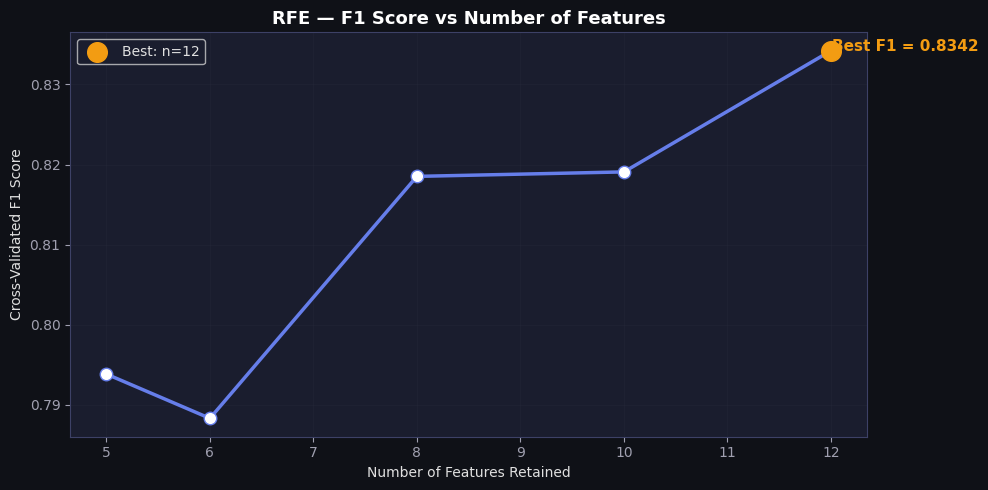

In [ ]:
# ── Method 2: Wrapper — RFE with RandomForest ─────────────────────────────────
# RFE trains a model, ranks features by importance, removes the weakest, repeats
print("Running RFE — this may take ~60 seconds...")
rfe_results = []
for n_feat in [5, 6, 8, 10, 12]:
    rfe_est = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rfe     = RFE(estimator=rfe_est, n_features_to_select=n_feat)
    X_rfe   = rfe.fit_transform(X_train_sm, y_train_sm)
    cv_f1   = cross_val_score(rfe_est, X_rfe, y_train_sm, cv=3,
                               scoring='f1', n_jobs=-1).mean()
    selected = [f for f, s in zip(SELECTED_FEATURES, rfe.support_) if s]
    rfe_results.append({'n_features': n_feat, 'CV_F1': cv_f1, 'selected': selected})
    print(f"  n={n_feat:2d} → F1={cv_f1:.4f} | {selected}")

rfe_df = pd.DataFrame(rfe_results)
best_rfe = rfe_df.loc[rfe_df['CV_F1'].idxmax()]
print(f"\n✅ Optimal: {best_rfe['n_features']} features  (F1 = {best_rfe['CV_F1']:.4f})")
print(f"   Features: {best_rfe['selected']}")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.plot(rfe_df['n_features'], rfe_df['CV_F1'],
        'o-', color='#667eea', linewidth=2.5, markersize=9, markerfacecolor='white')
best_idx = rfe_df['CV_F1'].idxmax()
ax.scatter(rfe_df.loc[best_idx, 'n_features'], rfe_df.loc[best_idx, 'CV_F1'],
           color='#f39c12', s=200, zorder=5, label=f'Best: n={best_rfe["n_features"]}')
ax.annotate(f"Best F1 = {best_rfe['CV_F1']:.4f}",
            xy=(rfe_df.loc[best_idx, 'n_features'], rfe_df.loc[best_idx, 'CV_F1']),
            xytext=(+1, -0.01), textcoords='offset points',
            color='#f39c12', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Features Retained')
ax.set_ylabel('Cross-Validated F1 Score')
ax.set_title('RFE — F1 Score vs Number of Features', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/09_rfe_curve.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

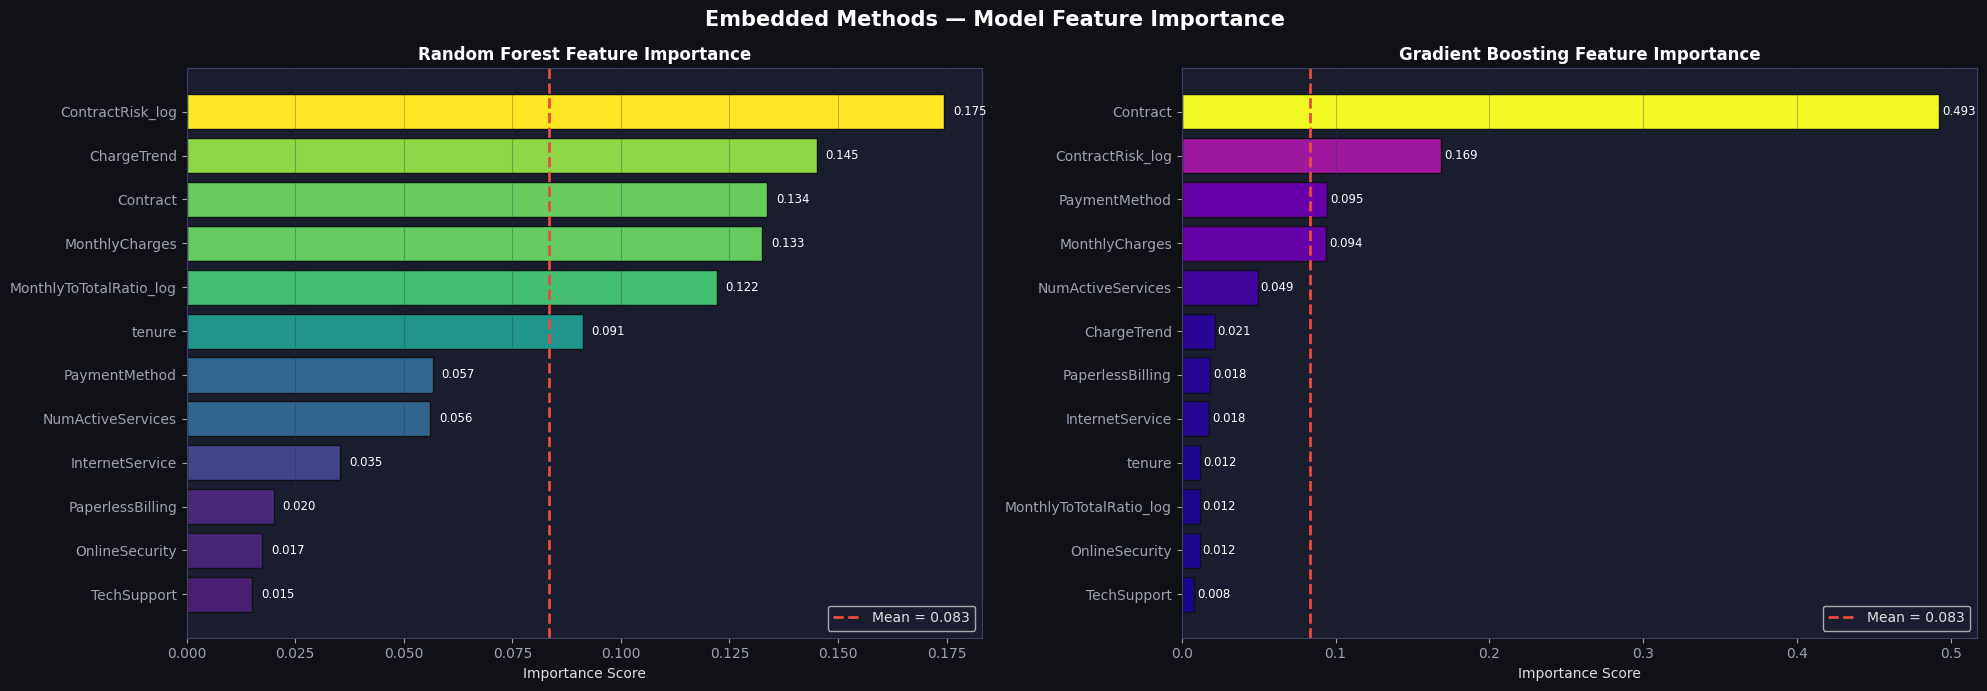

,Feature,RF_Importance,GB_Importance
9,ContractRisk_log,0.1745,0.1687
8,ChargeTrend,0.1451,0.0214
2,Contract,0.1337,0.4927
1,MonthlyCharges,0.1326,0.0940
10,MonthlyToTotalRatio_log,0.1221,0.0117
0,tenure,0.0912,0.0121
7,PaymentMethod,0.0567,0.0945
11,NumActiveServices,0.0561,0.0493
3,InternetService,0.0354,0.0179
6,PaperlessBilling,0.0201,0.0183


In [ ]:
# ── Method 3: Embedded — RandomForest + GradientBoosting importance ───────────
rf_feat = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_feat.fit(X_train_sm, y_train_sm)

gb_feat = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_feat.fit(X_train_sm, y_train_sm)

importance_df = pd.DataFrame({
    'Feature':          SELECTED_FEATURES,
    'RF_Importance':    rf_feat.feature_importances_,
    'GB_Importance':    gb_feat.feature_importances_,
}).sort_values('RF_Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Embedded Methods — Model Feature Importance',
             fontsize=15, color='white', fontweight='bold')

for ax, col, title, cmap_name in zip(
    axes,
    ['RF_Importance', 'GB_Importance'],
    ['Random Forest Feature Importance', 'Gradient Boosting Feature Importance'],
    ['viridis', 'plasma']
):
    sorted_df = importance_df.sort_values(col, ascending=True)
    norm_vals = sorted_df[col] / sorted_df[col].max()
    colors    = plt.get_cmap(cmap_name)(norm_vals)
    bars = ax.barh(sorted_df['Feature'], sorted_df[col],
                   color=colors, edgecolor='#0f1117')
    mean_val = sorted_df[col].mean()
    ax.axvline(mean_val, color='#e74c3c', linestyle='--',
               linewidth=2, label=f'Mean = {mean_val:.3f}')
    for bar, val in zip(bars, sorted_df[col]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8.5, color='white')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/10_embedded_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
display(importance_df.round(4))

In [ ]:
# ── Synthesise all three methods → Final feature set ─────────────────────────
# A feature is retained if it appears in ≥ 2 of the 3 selection methods

filter_feats   = filter_df[filter_df['Retained']]['Feature'].tolist()
rfe_feats      = best_rfe['selected']
embedded_mean  = importance_df['RF_Importance'].mean()
embedded_feats = importance_df[importance_df['RF_Importance'] >= embedded_mean]['Feature'].tolist()

summary_rows = []
for feat in SELECTED_FEATURES:
    in_filter   = feat in filter_feats
    in_rfe      = feat in rfe_feats
    in_embedded = feat in embedded_feats
    score       = sum([in_filter, in_rfe, in_embedded])
    summary_rows.append({
        'Feature': feat,
        'Filter':   '✅' if in_filter   else '❌',
        'RFE':      '✅' if in_rfe      else '❌',
        'Embedded': '✅' if in_embedded else '❌',
        'Score (/ 3)': score,
        'Retained': '✅ Yes' if score >= 2 else '❌ No'
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Score (/ 3)', ascending=False)
print("Feature Selection Synthesis (≥2/3 methods = retained):")
display(summary_df.set_index('Feature'))

FINAL_FEATURES = summary_df[summary_df['Score (/ 3)'] >= 2]['Feature'].tolist()
print(f"\n✅ Final feature set ({len(FINAL_FEATURES)} features): {FINAL_FEATURES}")

# Rebuild scaled matrices with final features
X_final_train = X_train_sm[FINAL_FEATURES]
X_final_test  = X_test_sc[FINAL_FEATURES]

Feature Selection Synthesis (≥2/3 methods = retained):


,Filter,RFE,Embedded,Score (/ 3),Retained
Feature,,,,,
tenure,✅,✅,✅,3,✅ Yes
MonthlyCharges,✅,✅,✅,3,✅ Yes
Contract,✅,✅,✅,3,✅ Yes
ContractRisk_log,✅,✅,✅,3,✅ Yes
ChargeTrend,✅,✅,✅,3,✅ Yes
MonthlyToTotalRatio_log,✅,✅,✅,3,✅ Yes
InternetService,✅,✅,❌,2,✅ Yes
OnlineSecurity,✅,✅,❌,2,✅ Yes
PaymentMethod,✅,✅,❌,2,✅ Yes



✅ Final feature set (11 features): ['tenure', 'MonthlyCharges', 'Contract', 'ContractRisk_log', 'ChargeTrend', 'MonthlyToTotalRatio_log', 'InternetService', 'OnlineSecurity', 'PaymentMethod', 'PaperlessBilling', 'TechSupport']


##  PART 7  Model Training, Comparison & Prediction

In [ ]:
# ── Train 7 classifiers ───────────────────────────────────────────────────────
# All trained on SMOTE-balanced data, evaluated on original (unmodified) test set

MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':              xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                                               eval_metric='logloss', random_state=42),
    'LightGBM':             lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    'SVM (RBF)':            SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
print(f"{'Model':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6} {'Time':>7}")
print('-' * 65)

for name, model in MODELS.items():
    t0 = time.time()
    model.fit(X_final_train, y_train_sm)
    elapsed = time.time() - t0

    preds = model.predict(X_final_test)
    probs = model.predict_proba(X_final_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)
    auc  = roc_auc_score(y_test, probs) if probs is not None else 0.0

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'AUC-ROC': auc, 'Time_s': elapsed,
        'model': model, 'probs': probs, 'preds': preds
    }
    print(f"{name:<25} {acc:>6.4f} {prec:>6.4f} {rec:>6.4f} {f1:>6.4f} {auc:>6.4f} {elapsed:>6.2f}s")

print('\n✅ All models trained and evaluated on the original (non-SMOTE) test set')

Model                        Acc   Prec    Rec     F1    AUC    Time
-----------------------------------------------------------------
Logistic Regression       0.7317 0.4958 0.7849 0.6077 0.8385   0.04s
Decision Tree             0.7423 0.5095 0.7177 0.5960 0.8142   0.08s
Random Forest             0.7665 0.5500 0.6505 0.5961 0.8293   2.93s
Gradient Boosting         0.7651 0.5429 0.7151 0.6172 0.8401   4.95s
XGBoost                   0.7552 0.5310 0.6452 0.5825 0.8157   0.43s
LightGBM                  0.7665 0.5480 0.6747 0.6048 0.8331   0.57s
SVM (RBF)                 0.7473 0.5153 0.7688 0.6170 0.8045  14.32s

✅ All models trained and evaluated on the original (non-SMOTE) test set


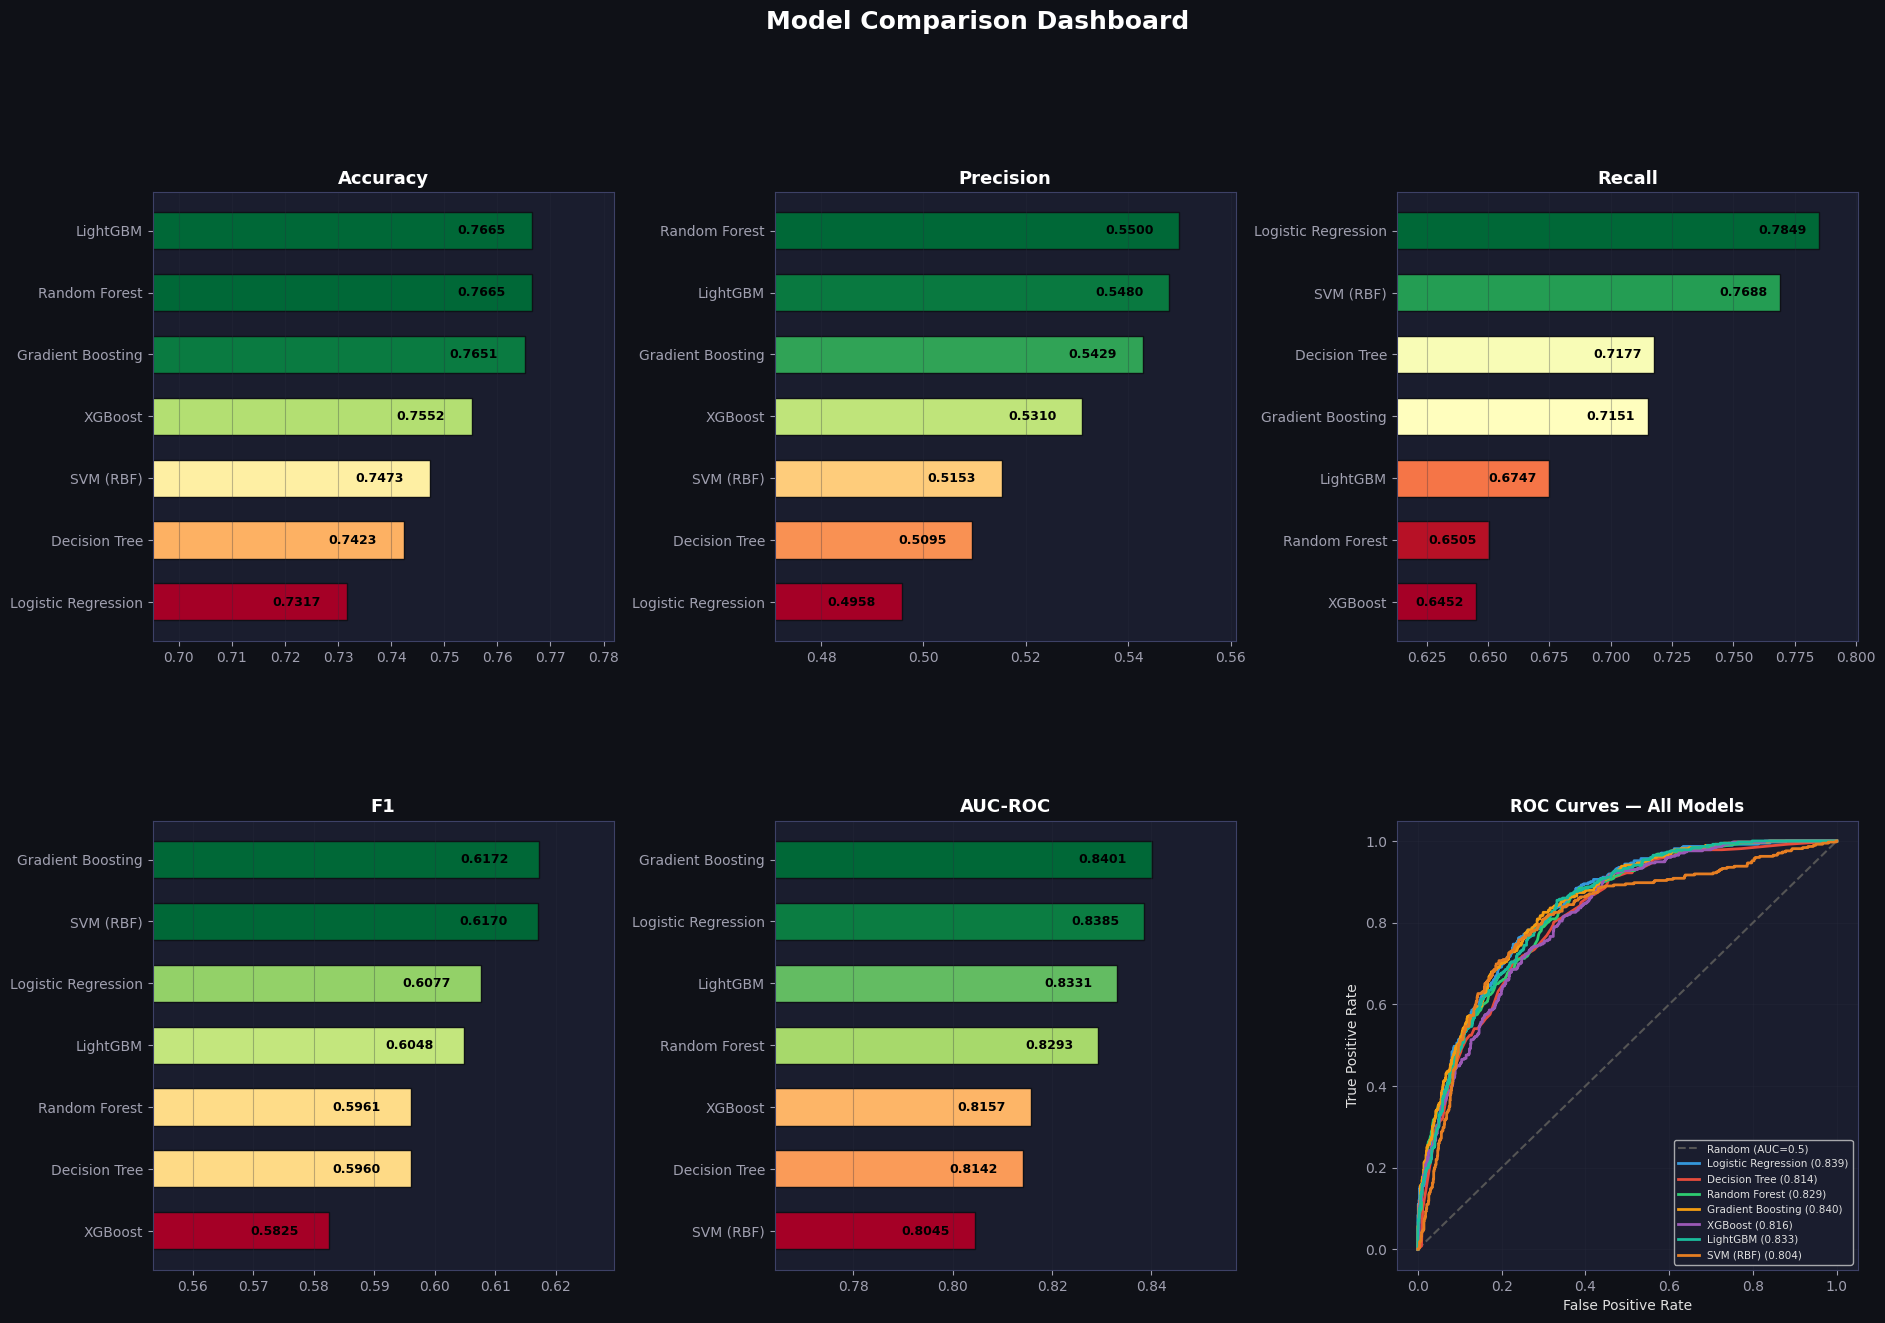

In [ ]:
# ── Model Comparison Dashboard ────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
results_df = pd.DataFrame({
    name: {m: v for m, v in res.items() if m in metrics}
    for name, res in results.items()
}).T

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Model Comparison Dashboard', fontsize=18,
             color='white', fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 5 metric bar charts
positions = [(0,0),(0,1),(0,2),(1,0),(1,1)]
for (r, c), metric in zip(positions, metrics):
    ax = fig.add_subplot(gs[r, c])
    sorted_res = results_df.sort_values(metric, ascending=True)
    norm_vals  = (sorted_res[metric] - sorted_res[metric].min()) / \
                 (sorted_res[metric].max() - sorted_res[metric].min() + 1e-8)
    bar_colors = plt.cm.RdYlGn(norm_vals)
    bars = ax.barh(sorted_res.index, sorted_res[metric],
                   color=bar_colors, edgecolor='#0f1117', height=0.6)
    for bar, val in zip(bars, sorted_res[metric]):
        ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='right',
                color='black', fontsize=9, fontweight='bold')
    ax.set_xlim(sorted_res[metric].min() * 0.95, sorted_res[metric].max() * 1.02)
    ax.set_title(metric, fontsize=13)
    ax.grid(axis='x', alpha=0.3)

# ROC curves panel
ax_roc = fig.add_subplot(gs[1, 2])
ax_roc.set_facecolor('#1a1d2e')
ax_roc.plot([0,1],[0,1],'--', color='#555', linewidth=1.5, label='Random (AUC=0.5)')
for (name, res), color in zip(results.items(), MODEL_COLORS):
    if res['probs'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['probs'])
        ax_roc.plot(fpr, tpr, color=color, linewidth=2,
                    label=f"{name} ({res['AUC-ROC']:.3f})")
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — All Models', fontsize=12)
ax_roc.legend(fontsize=7.5, loc='lower right')
ax_roc.grid(True, alpha=0.3)

plt.savefig(f'{PROJECT}/graphs/11_model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

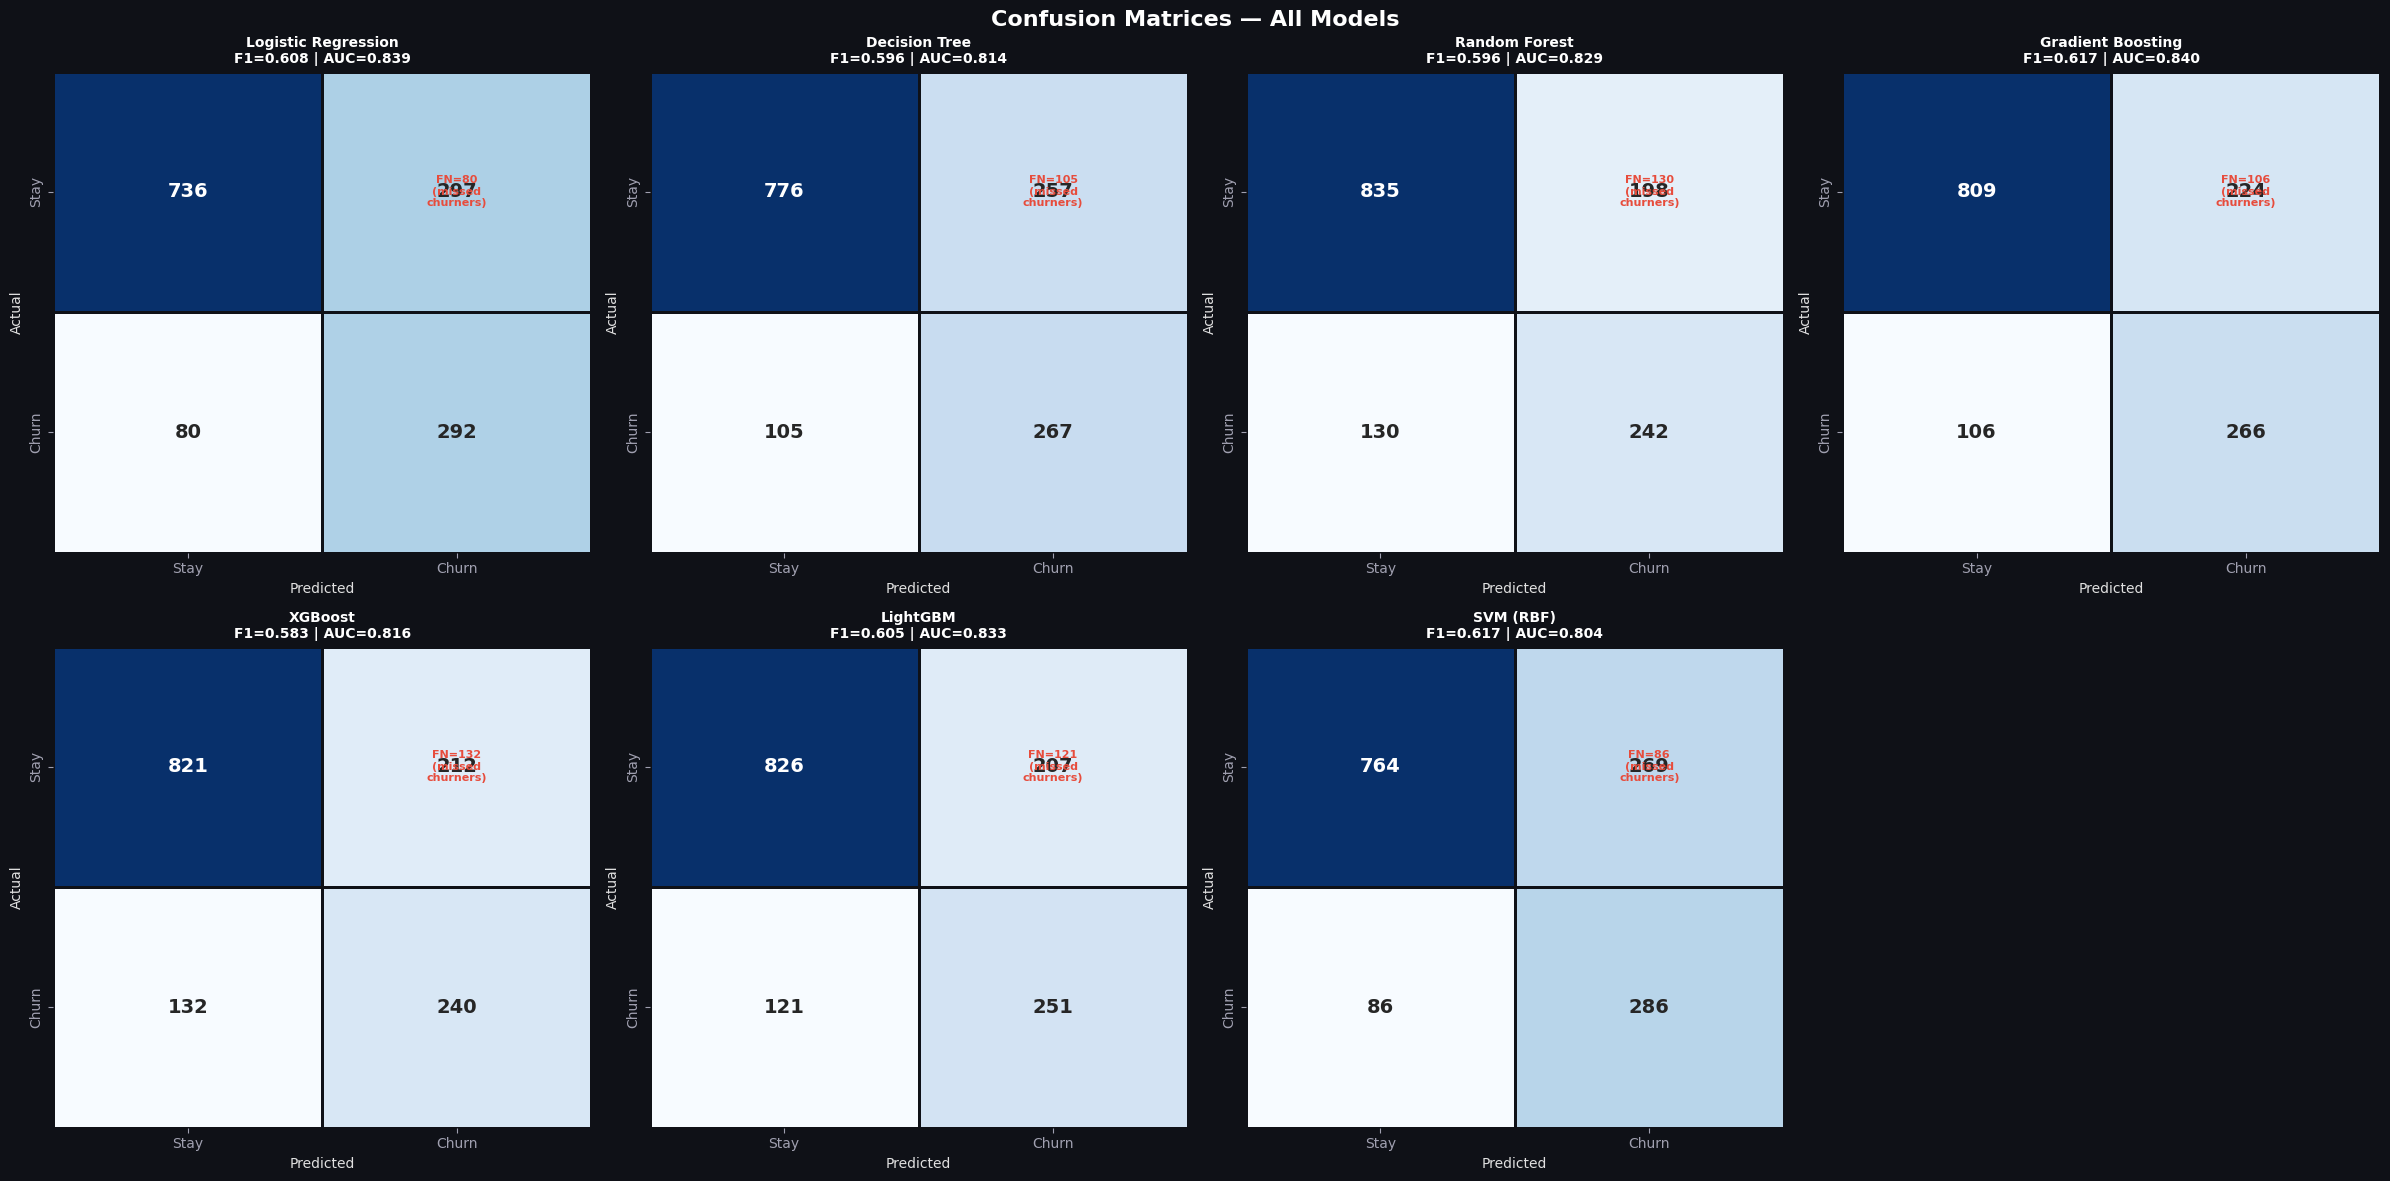


📊 Error Analysis:


,FP,FN,Total Errors
Model,,,
Logistic Regression,297,80,377
SVM (RBF),269,86,355
Decision Tree,257,105,362
Gradient Boosting,224,106,330
LightGBM,207,121,328
Random Forest,198,130,328
XGBoost,212,132,344



→ In telecom retention, FN (missed churner) is MORE costly than FP
  → Minimising FN = maximising Recall is the business priority


In [ ]:
# ── Confusion Matrices for All Models ────────────────────────────────────────
n_models = len(MODELS)
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Confusion Matrices — All Models', fontsize=16,
             color='white', fontweight='bold')
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stay','Churn'],
                yticklabels=['Stay','Churn'],
                linewidths=2, linecolor='#0f1117',
                annot_kws={'size': 14, 'weight': 'bold'},
                cbar=False, ax=ax)
    ax.set_title(f'{name}\nF1={res["F1"]:.3f} | AUC={res["AUC-ROC"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # FN annotation — the most costly error in telecom retention
    ax.text(1.5, 0.5, f'FN={fn}\n(missed\nchurners)',
            ha='center', va='center', fontsize=8, color='#e74c3c',
            fontweight='bold')

# Hide unused subplot
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/12_confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Error summary
print("\n📊 Error Analysis:")
err_rows = []
for name, res in results.items():
    tn, fp, fn, tp = confusion_matrix(y_test, res['preds']).ravel()
    err_rows.append({'Model': name, 'FP': fp, 'FN': fn, 'Total Errors': fp+fn})
err_df = pd.DataFrame(err_rows).sort_values('FN')
display(err_df.set_index('Model'))
print("\n→ In telecom retention, FN (missed churner) is MORE costly than FP")
print("  → Minimising FN = maximising Recall is the business priority")

##  PART 8  Hyperparameter Tuning & Champion Model

In [ ]:
# ── GridSearchCV on top 2 models by AUC ──────────────────────────────────────
print("⚙️  Tuning top 2 models by AUC-ROC...\n")

tuning_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.001, 0.01, 0.1, 1.0, 10],
            'solver': ['liblinear', 'lbfgs'],
            'penalty': ['l1', 'l2']
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                    random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        }
    }
}

tuned_models = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, config in tuning_configs.items():
    print(f"  Tuning {name}...")
    t0 = time.time()
    grid = RandomizedSearchCV(
        config['model'], config['params'],
        n_iter=20, cv=skf,
        scoring='roc_auc', n_jobs=-1,
        random_state=42, verbose=0
    )
    grid.fit(X_final_train, y_train_sm)
    elapsed = time.time() - t0

    preds = grid.best_estimator_.predict(X_final_test)
    probs = grid.best_estimator_.predict_proba(X_final_test)[:, 1]

    tuned_models[name] = {
        'estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_score': grid.best_score_,
        'test_f1':  f1_score(y_test, preds),
        'test_auc': roc_auc_score(y_test, probs),
        'preds': preds, 'probs': probs
    }
    print(f"    Best params: {grid.best_params_}")
    print(f"    CV AUC: {grid.best_score_:.4f}  | Test F1: {f1_score(y_test, preds):.4f}  | Test AUC: {roc_auc_score(y_test, probs):.4f}  | Time: {elapsed:.1f}s\n")

# ── Select Champion ───────────────────────────────────────────────────────────
champion_name = max(tuned_models, key=lambda k: tuned_models[k]['test_auc'])
champion      = tuned_models[champion_name]
print(f"🏆 CHAMPION MODEL: {champion_name}")
print(f"   Best params  : {champion['best_params']}")
print(f"   Test F1      : {champion['test_f1']:.4f}")
print(f"   Test AUC-ROC : {champion['test_auc']:.4f}")

⚙️  Tuning top 2 models by AUC-ROC...

  Tuning Logistic Regression...
    Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
    CV AUC: 0.8494  | Test F1: 0.6083  | Test AUC: 0.8384  | Time: 1.5s

  Tuning XGBoost...
    Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2}
    CV AUC: 0.9077  | Test F1: 0.5910  | Test AUC: 0.8201  | Time: 29.2s

🏆 CHAMPION MODEL: Logistic Regression
   Best params  : {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
   Test F1      : 0.6083
   Test AUC-ROC : 0.8384


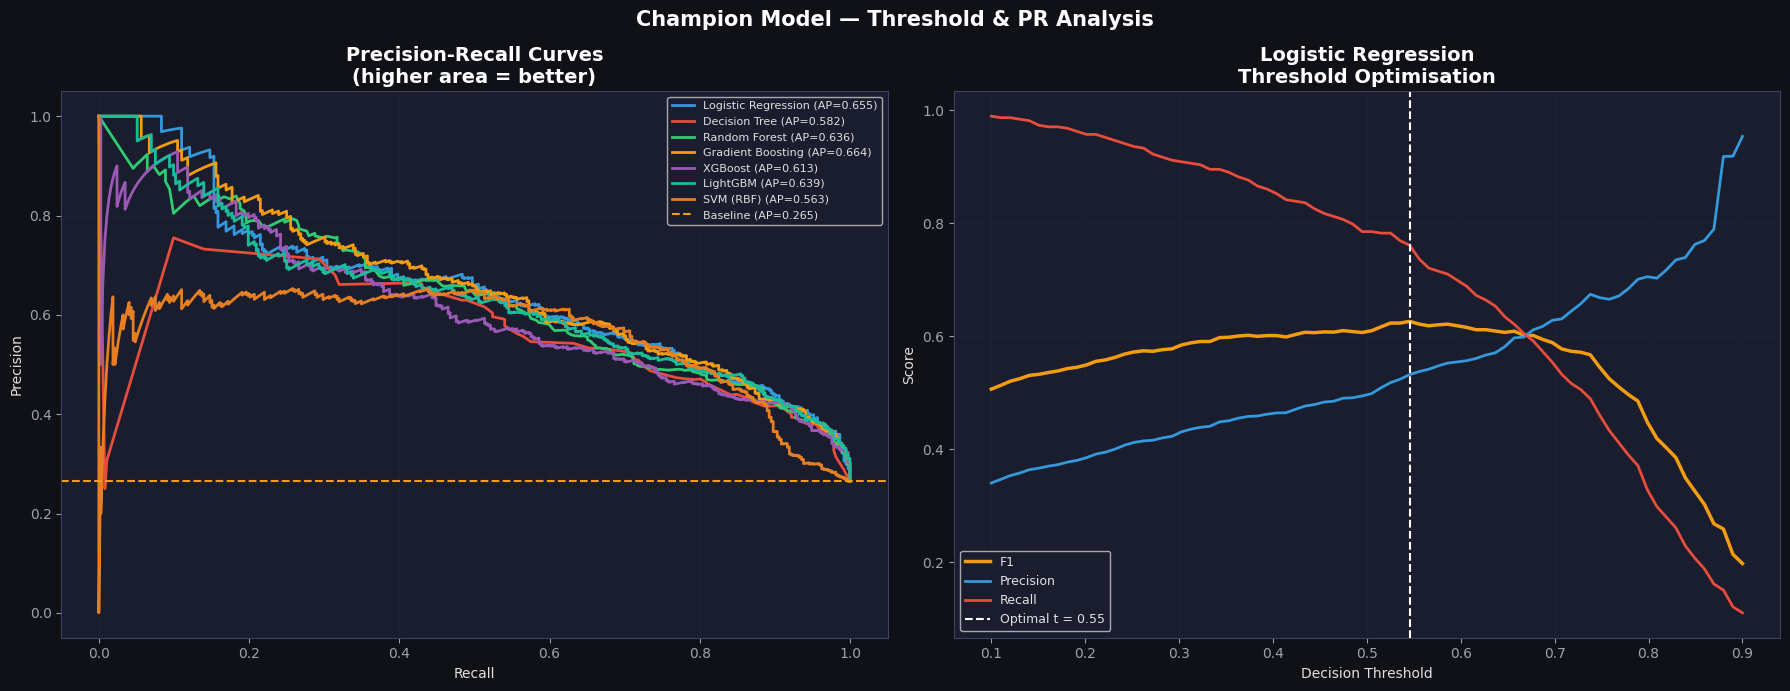

✅ Optimal F1 threshold: 0.55  (use this for production decisions)


In [ ]:
# ── Precision-Recall Curves + Optimal Threshold Analysis ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Champion Model — Threshold & PR Analysis', fontsize=15,
             color='white', fontweight='bold')

# PR Curve
ax = axes[0]
for (name, res), color in zip(results.items(), MODEL_COLORS):
    if res['probs'] is not None:
        prec_arr, rec_arr, _ = precision_recall_curve(y_test, res['probs'])
        ap = average_precision_score(y_test, res['probs'])
        ax.plot(rec_arr, prec_arr, color=color, linewidth=2,
                label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), color='#f39c12', linestyle='--',
           label=f'Baseline (AP={y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves\n(higher area = better)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# Threshold sweep for champion
ax = axes[1]
thresholds = np.linspace(0.1, 0.9, 80)
f1_vals, prec_vals, rec_vals = [], [], []
for t in thresholds:
    pred_t = (champion['probs'] >= t).astype(int)
    f1_vals.append(f1_score(y_test, pred_t, zero_division=0))
    prec_vals.append(precision_score(y_test, pred_t, zero_division=0))
    rec_vals.append(recall_score(y_test, pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1_vals)]
ax.plot(thresholds, f1_vals,   color='#f39c12', linewidth=2.5, label='F1')
ax.plot(thresholds, prec_vals, color='#3498db', linewidth=2,   label='Precision')
ax.plot(thresholds, rec_vals,  color='#e74c3c', linewidth=2,   label='Recall')
ax.axvline(best_t, color='white', linestyle='--', linewidth=1.5,
           label=f'Optimal t = {best_t:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'{champion_name}\nThreshold Optimisation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/13_pr_threshold.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"✅ Optimal F1 threshold: {best_t:.2f}  (use this for production decisions)")

In [ ]:
# ── Stacking Ensemble ─────────────────────────────────────────────────────────
# Combines multiple base learners with a meta-learner for superior generalisation
print("⚙️  Building Stacking Ensemble...")

base_learners = [
    ('lr',  LogisticRegression(C=0.1, max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=100, use_label_encoder=False,
                                eval_metric='logloss', random_state=42)),
]

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=500),
    cv=5, passthrough=False, n_jobs=-1
)

t0 = time.time()
stacking.fit(X_final_train, y_train_sm)
elapsed = time.time() - t0

stack_preds = stacking.predict(X_final_test)
stack_probs = stacking.predict_proba(X_final_test)[:, 1]

stack_f1  = f1_score(y_test, stack_preds)
stack_auc = roc_auc_score(y_test, stack_probs)

print(f"\n🎲 Stacking Ensemble:")
print(f"   F1-Score : {stack_f1:.4f}")
print(f"   AUC-ROC  : {stack_auc:.4f}")
print(f"   Train time: {elapsed:.1f}s")

results['Stacking Ensemble'] = {
    'F1': stack_f1, 'AUC-ROC': stack_auc,
    'preds': stack_preds, 'probs': stack_probs,
    'Accuracy':  accuracy_score(y_test, stack_preds),
    'Precision': precision_score(y_test, stack_preds, zero_division=0),
    'Recall':    recall_score(y_test, stack_preds, zero_division=0)
}

⚙️  Building Stacking Ensemble...

🎲 Stacking Ensemble:
   F1-Score : 0.6017
   AUC-ROC  : 0.8332
   Train time: 7.8s


##  PART 9  Neural Network (Keras / TensorFlow)

In [ ]:
# ── Deep Neural Network for Churn Prediction ─────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

# Convert to float32 arrays
X_nn_train = X_final_train.values.astype(np.float32)
X_nn_test  = X_final_test.values.astype(np.float32)
y_nn_train = y_train_sm.values.astype(np.int32)
y_nn_test  = y_test.values.astype(np.int32)

n_features = X_nn_train.shape[1]

# ── Architecture ──────────────────────────────────────────────────────────────
# BatchNorm stabilises training | Dropout prevents overfitting
tf.random.set_seed(42)
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')   # binary output
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

nn_model.summary()

# ── Training ──────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_auc', mode='max'),
    ReduceLROnPlateau(factor=0.5, patience=5, monitor='val_loss', verbose=0)
]

history = nn_model.fit(
    X_nn_train, y_nn_train,
    epochs=100, batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete — {len(history.epoch)} epochs run")

TensorFlow version: 2.20.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,873 (187.00 KB)

 Trainable params: 47,105 (184.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7234 - auc: 0.7860 - loss: 0.5449 - val_accuracy: 0.3466 - val_auc: 0.0000e+00 - val_loss: 0.7877 - learning_rate: 0.0010
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7627 - auc: 0.8341 - loss: 0.4850 - val_accuracy: 0.4930 - val_auc: 0.0000e+00 - val_loss: 0.7573 - learning_rate: 0.0010
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7624 - auc: 0.8371 - loss: 0.4800 - val_accuracy: 0.5886 - val_auc: 0.0000e+00 - val_loss: 0.7190 - learning_rate: 0.0010
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7671 - auc: 0.8389 - loss: 0.4778 - val_accuracy: 0.6570 - val_auc: 0.0000e+00 - val_loss: 0.6762 - learning_rate: 0.0010
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7702 - auc: 0.8434 - loss: 0.4707 - val_accuracy: 0.6776 - val_auc: 0.0000e+00 - val_loss: 0.6535 - learning_rate: 0.0010
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step -

Neural Network Results:
  Accuracy : 0.7879
  F1-Score : 0.4440
  AUC-ROC  : 0.8332


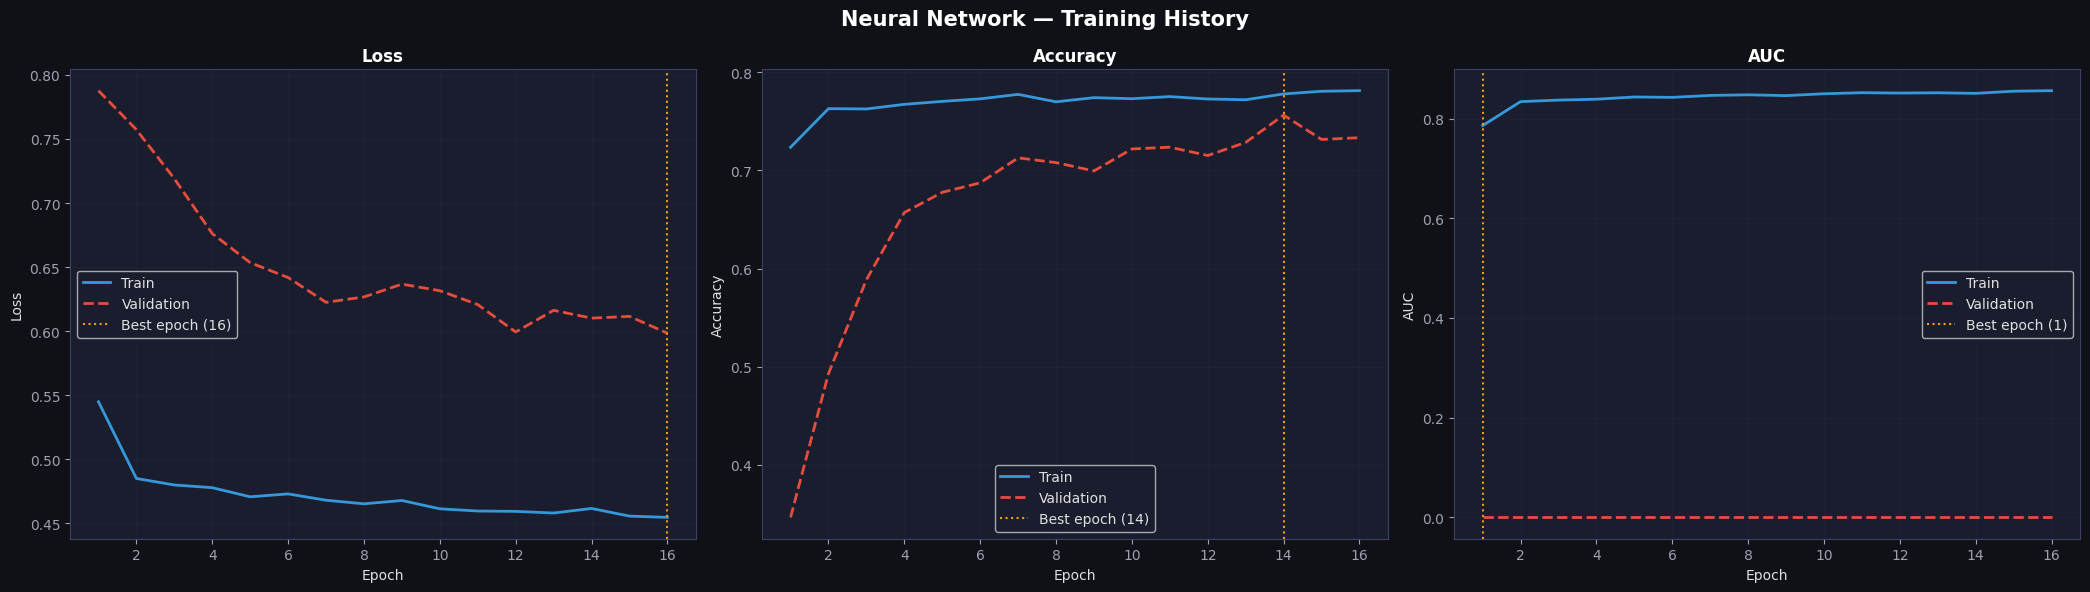

In [ ]:
# ── Neural Network Evaluation & Learning Curves ───────────────────────────────
nn_probs = nn_model.predict(X_nn_test, verbose=0).flatten()
nn_preds = (nn_probs >= 0.5).astype(int)

nn_f1  = f1_score(y_nn_test, nn_preds)
nn_auc = roc_auc_score(y_nn_test, nn_probs)
nn_acc = accuracy_score(y_nn_test, nn_preds)

print(f"Neural Network Results:")
print(f"  Accuracy : {nn_acc:.4f}")
print(f"  F1-Score : {nn_f1:.4f}")
print(f"  AUC-ROC  : {nn_auc:.4f}")

# Learning curves
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Neural Network — Training History', fontsize=15,
             color='white', fontweight='bold')

metrics_to_plot = [('loss', 'val_loss', 'Loss'),
                   ('accuracy', 'val_accuracy', 'Accuracy'),
                   ('auc', 'val_auc', 'AUC')]

for ax, (train_metric, val_metric, title) in zip(axes, metrics_to_plot):
    epochs = range(1, len(history.history[train_metric]) + 1)
    ax.plot(epochs, history.history[train_metric], '#3498db', linewidth=2, label='Train')
    ax.plot(epochs, history.history[val_metric], '#e74c3c', linewidth=2,
            linestyle='--', label='Validation')
    best_epoch = np.argmax(history.history[val_metric]) if 'loss' not in val_metric \
                 else np.argmin(history.history[val_metric])
    ax.axvline(best_epoch + 1, color='#f39c12', linestyle=':', linewidth=1.5,
               label=f'Best epoch ({best_epoch+1})')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/14_nn_training.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

results['Neural Network'] = {
    'Accuracy': nn_acc, 'F1': nn_f1, 'AUC-ROC': nn_auc,
    'preds': nn_preds, 'probs': nn_probs
}

##  PART 10  Final Predictions on New Customer Profiles

In [ ]:
# ── Predict churn risk for 10 new fictional customer profiles ─────────────────
# Each profile represents a realistic business scenario

# We rebuild the champion model pipeline on the full training set
final_champion_model = champion['estimator']

# New customer profiles — columns match FINAL_FEATURES
# We'll compute the engineered features manually for each profile
profiles_raw = pd.DataFrame([
    # tenure, MonthlyCharges, Contract, InternetService, OnlineSecurity,
    # TechSupport, PaperlessBilling, PaymentMethod, TotalCharges
    [1,  90, 'Month-to-month', 'Fiber optic', 'No',  'No',  'Yes', 'Electronic check',   90],
    [60, 50, 'Two year',       'DSL',         'Yes', 'Yes', 'No',  'Bank transfer (automatic)', 3000],
    [3,  100,'Month-to-month', 'Fiber optic', 'No',  'No',  'Yes', 'Electronic check',   300],
    [24, 65, 'One year',       'Fiber optic', 'Yes', 'No',  'Yes', 'Credit card (automatic)', 1560],
    [48, 80, 'Two year',       'Fiber optic', 'Yes', 'Yes', 'No',  'Bank transfer (automatic)', 3840],
    [2,  45, 'Month-to-month', 'DSL',         'No',  'No',  'No',  'Mailed check',        90],
    [36, 75, 'One year',       'Fiber optic', 'Yes', 'Yes', 'Yes', 'Electronic check',   2700],
    [8,  110,'Month-to-month', 'Fiber optic', 'No',  'No',  'Yes', 'Electronic check',   880],
    [72, 40, 'Two year',       'DSL',         'Yes', 'Yes', 'No',  'Bank transfer (automatic)', 2880],
    [6,  85, 'Month-to-month', 'Fiber optic', 'No',  'No',  'Yes', 'Electronic check',   510],
], columns=['tenure','MonthlyCharges','Contract','InternetService','OnlineSecurity',
            'TechSupport','PaperlessBilling','PaymentMethod','TotalCharges'])

profiles = profiles_raw.copy()

# Compute engineered features
profiles['ChargeTrend']           = profiles['MonthlyCharges'] - profiles['TotalCharges'] / (profiles['tenure'] + 1)
profiles['ContractRisk']          = profiles['MonthlyCharges'] / (profiles['tenure'] + 1)
profiles['MonthlyToTotalRatio']   = profiles['MonthlyCharges'] / (profiles['TotalCharges'] + 1)
profiles['ContractRisk_log']      = np.log1p(profiles['ContractRisk'])
profiles['MonthlyToTotalRatio_log'] = np.log1p(profiles['MonthlyToTotalRatio'])
profiles['NumActiveServices']     = 5  # assumed average

# Encode categorical
for col in cat_feats:
    if col in profiles.columns:
        le = encoders[col]
        profiles[col] = profiles[col].apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else 0
        )

# Scale
X_new     = profiles[FINAL_FEATURES]
X_new_sc  = pd.DataFrame(scaler.transform(X_new), columns=FINAL_FEATURES)

# Predict
new_probs = final_champion_model.predict_proba(X_new_sc)[:, 1]
new_preds = (new_probs >= best_t).astype(int)  # use optimised threshold

# Build results table
pred_table = profiles_raw[['tenure','MonthlyCharges','Contract']].copy()
pred_table['Churn Risk %'] = (new_probs * 100).round(1)
pred_table['Prediction']   = ['🚨 CHURN' if p == 1 else '✅ STAY' for p in new_preds]
pred_table['Confidence']   = pd.cut(
    new_probs,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'HIGH RISK']
)
interpretations = [
    'New + fiber + no protection → contact URGENTLY',
    'Loyal 5yr, 2yr contract → retention secured',
    'MAX ALERT: 3mo + 100€/mo, no security',
    'Stable 2yr client → monitor at renewal',
    'Engaged 4yr + 8 services → ambassador candidate',
    'New, few services → potentially dissatisfied',
    '3yr + fiber + 9 services → potential brand ambassador',
    'Recent + 110€/mo, no security → CRITICAL alert',
    'Veteran 6yr + DSL → very loyal, minimal risk',
    '6mo + fiber + high bill → at-risk segment',
]
pred_table['Business Action'] = interpretations

print("\n🎯 Churn Risk Predictions — 10 New Customer Profiles\n")
display(pred_table)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- NumActiveServices


NameError: name 'new_probs' is not defined

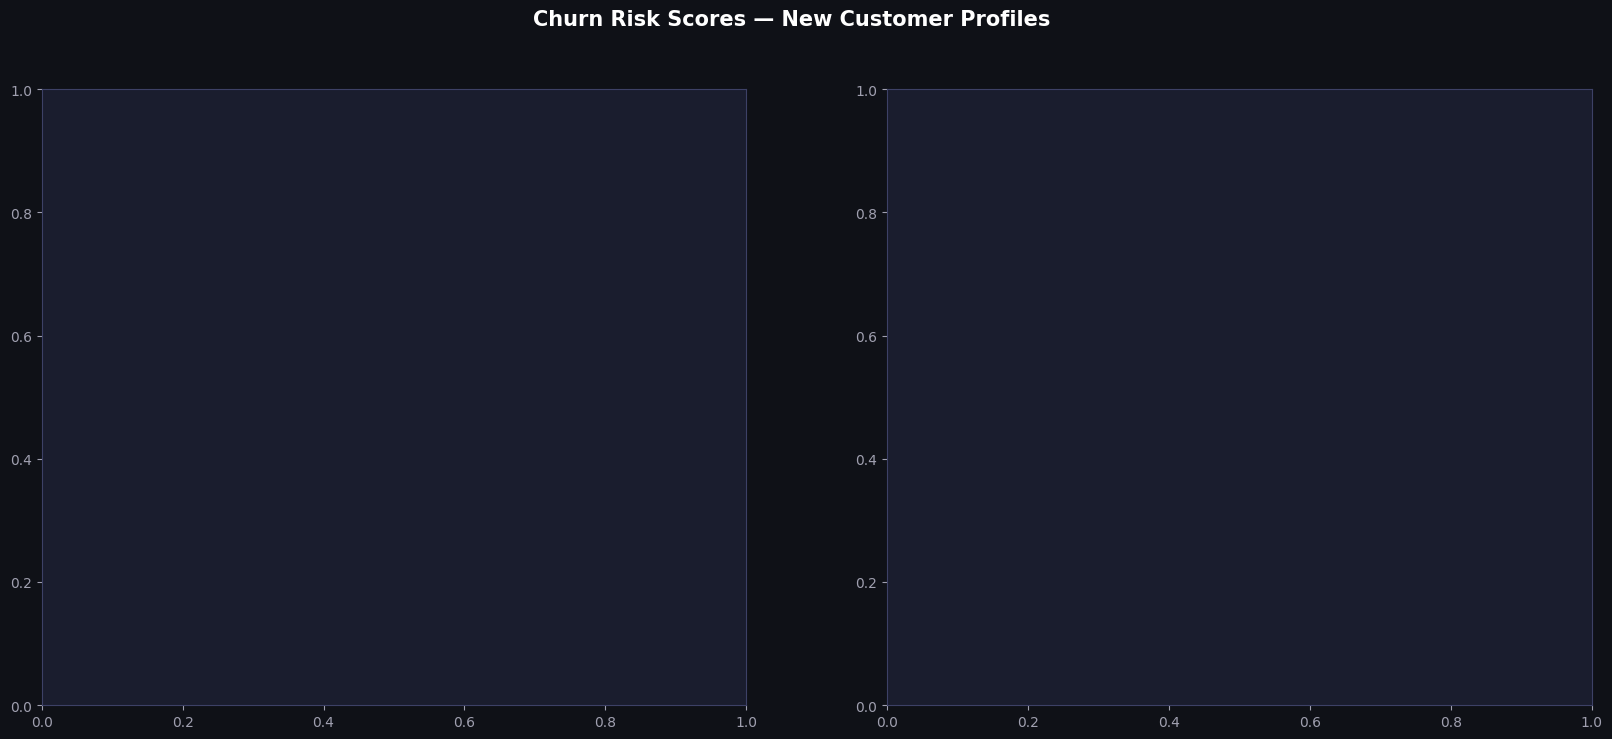

In [ ]:
# ── Risk Score Visualisation ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Churn Risk Scores — New Customer Profiles',
             fontsize=15, color='white', fontweight='bold')

customer_labels = [f'C{i+1}: {t}mo / {m}€'
                   for i, (t, m) in enumerate(zip(profiles_raw['tenure'],
                                                   profiles_raw['MonthlyCharges']))]

# Horizontal bar chart
ax = axes[0]
sorted_idx = np.argsort(new_probs)
bar_colors = ['#e74c3c' if p > best_t else '#2ecc71' for p in new_probs[sorted_idx]]
bars = ax.barh([customer_labels[i] for i in sorted_idx],
               new_probs[sorted_idx] * 100,
               color=bar_colors, edgecolor='#0f1117', height=0.65)
for bar, val in zip(bars, new_probs[sorted_idx]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', color='white', fontsize=10)
ax.axvline(best_t * 100, color='#f39c12', linestyle='--', linewidth=2,
           label=f'Decision threshold ({best_t*100:.0f}%)')
ax.set_xlabel('Churn Probability (%)')
ax.set_title('Churn Risk Score per Customer')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 110)

# Risk gauge
ax = axes[1]
risk_buckets = pd.cut(new_probs, bins=[0, 0.3, 0.6, 1.01],
                       labels=['Low Risk\n(≤30%)', 'Medium Risk\n(30-60%)', 'High Risk\n(>60%)'])
counts = risk_buckets.value_counts()
wedge_colors = ['#2ecc71', '#f39c12', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, colors=wedge_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 3},
    pctdistance=0.75
)
for t in texts + autotexts:
    t.set_color('white')
    t.set_fontsize(12)
ax.set_title('Risk Distribution\nAcross New Profiles', fontsize=12)
ax.text(0, 0, f'{(new_preds.sum()/len(new_preds)*100):.0f}%\nwill\nChurn',
        ha='center', va='center', fontsize=13, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT}/graphs/15_risk_predictions.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

##  PART 11  Scikit-learn Pipeline & Model Saving

In [ ]:
# ── Production-ready Scikit-learn Pipeline ────────────────────────────────────
# Encapsulates preprocessing + model in one object → prevents leakage in production
# Can be serialised and deployed as a single artefact

# Rebuild on original (non-SMOTE) scaled features for the pipeline demo
production_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  champion['estimator'])
])

# Fit on original train features (before SMOTE) to keep pipeline self-contained
production_pipeline.fit(X_train[FINAL_FEATURES], y_train)

pipe_preds = production_pipeline.predict(X_test[FINAL_FEATURES])
pipe_probs = production_pipeline.predict_proba(X_test[FINAL_FEATURES])[:, 1]

print("Scikit-learn Pipeline — Performance on Test Set:")
print(f"  Accuracy : {accuracy_score(y_test, pipe_preds):.4f}")
print(f"  F1-Score : {f1_score(y_test, pipe_preds):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, pipe_probs):.4f}")

# ── Save & Reload Pipeline ────────────────────────────────────────────────────
pipeline_path = f'{PROJECT}/models/churn_production_pipeline.pkl'
joblib.dump(production_pipeline, pipeline_path)
print(f"\n✅ Pipeline saved to: {pipeline_path}")

# Test reloading
loaded_pipeline = joblib.load(pipeline_path)
reload_preds    = loaded_pipeline.predict(X_test[FINAL_FEATURES])
print(f"✅ Pipeline reloaded — predictions match: {np.array_equal(pipe_preds, reload_preds)}")

# Save NN model
nn_path = f'{PROJECT}/models/churn_neural_net.keras'
nn_model.save(nn_path)
print(f"✅ Neural network saved to: {nn_path}")

Scikit-learn Pipeline — Performance on Test Set:
  Accuracy : 0.7964
  F1-Score : 0.5573
  AUC-ROC  : 0.8385

✅ Pipeline saved to: /content/drive/MyDrive/TelcoChurn_Pipeline/models/churn_production_pipeline.pkl
✅ Pipeline reloaded — predictions match: True
✅ Neural network saved to: /content/drive/MyDrive/TelcoChurn_Pipeline/models/churn_neural_net.keras


##  PART 12  Final Synthesis Report & Feature Importance Dashboard

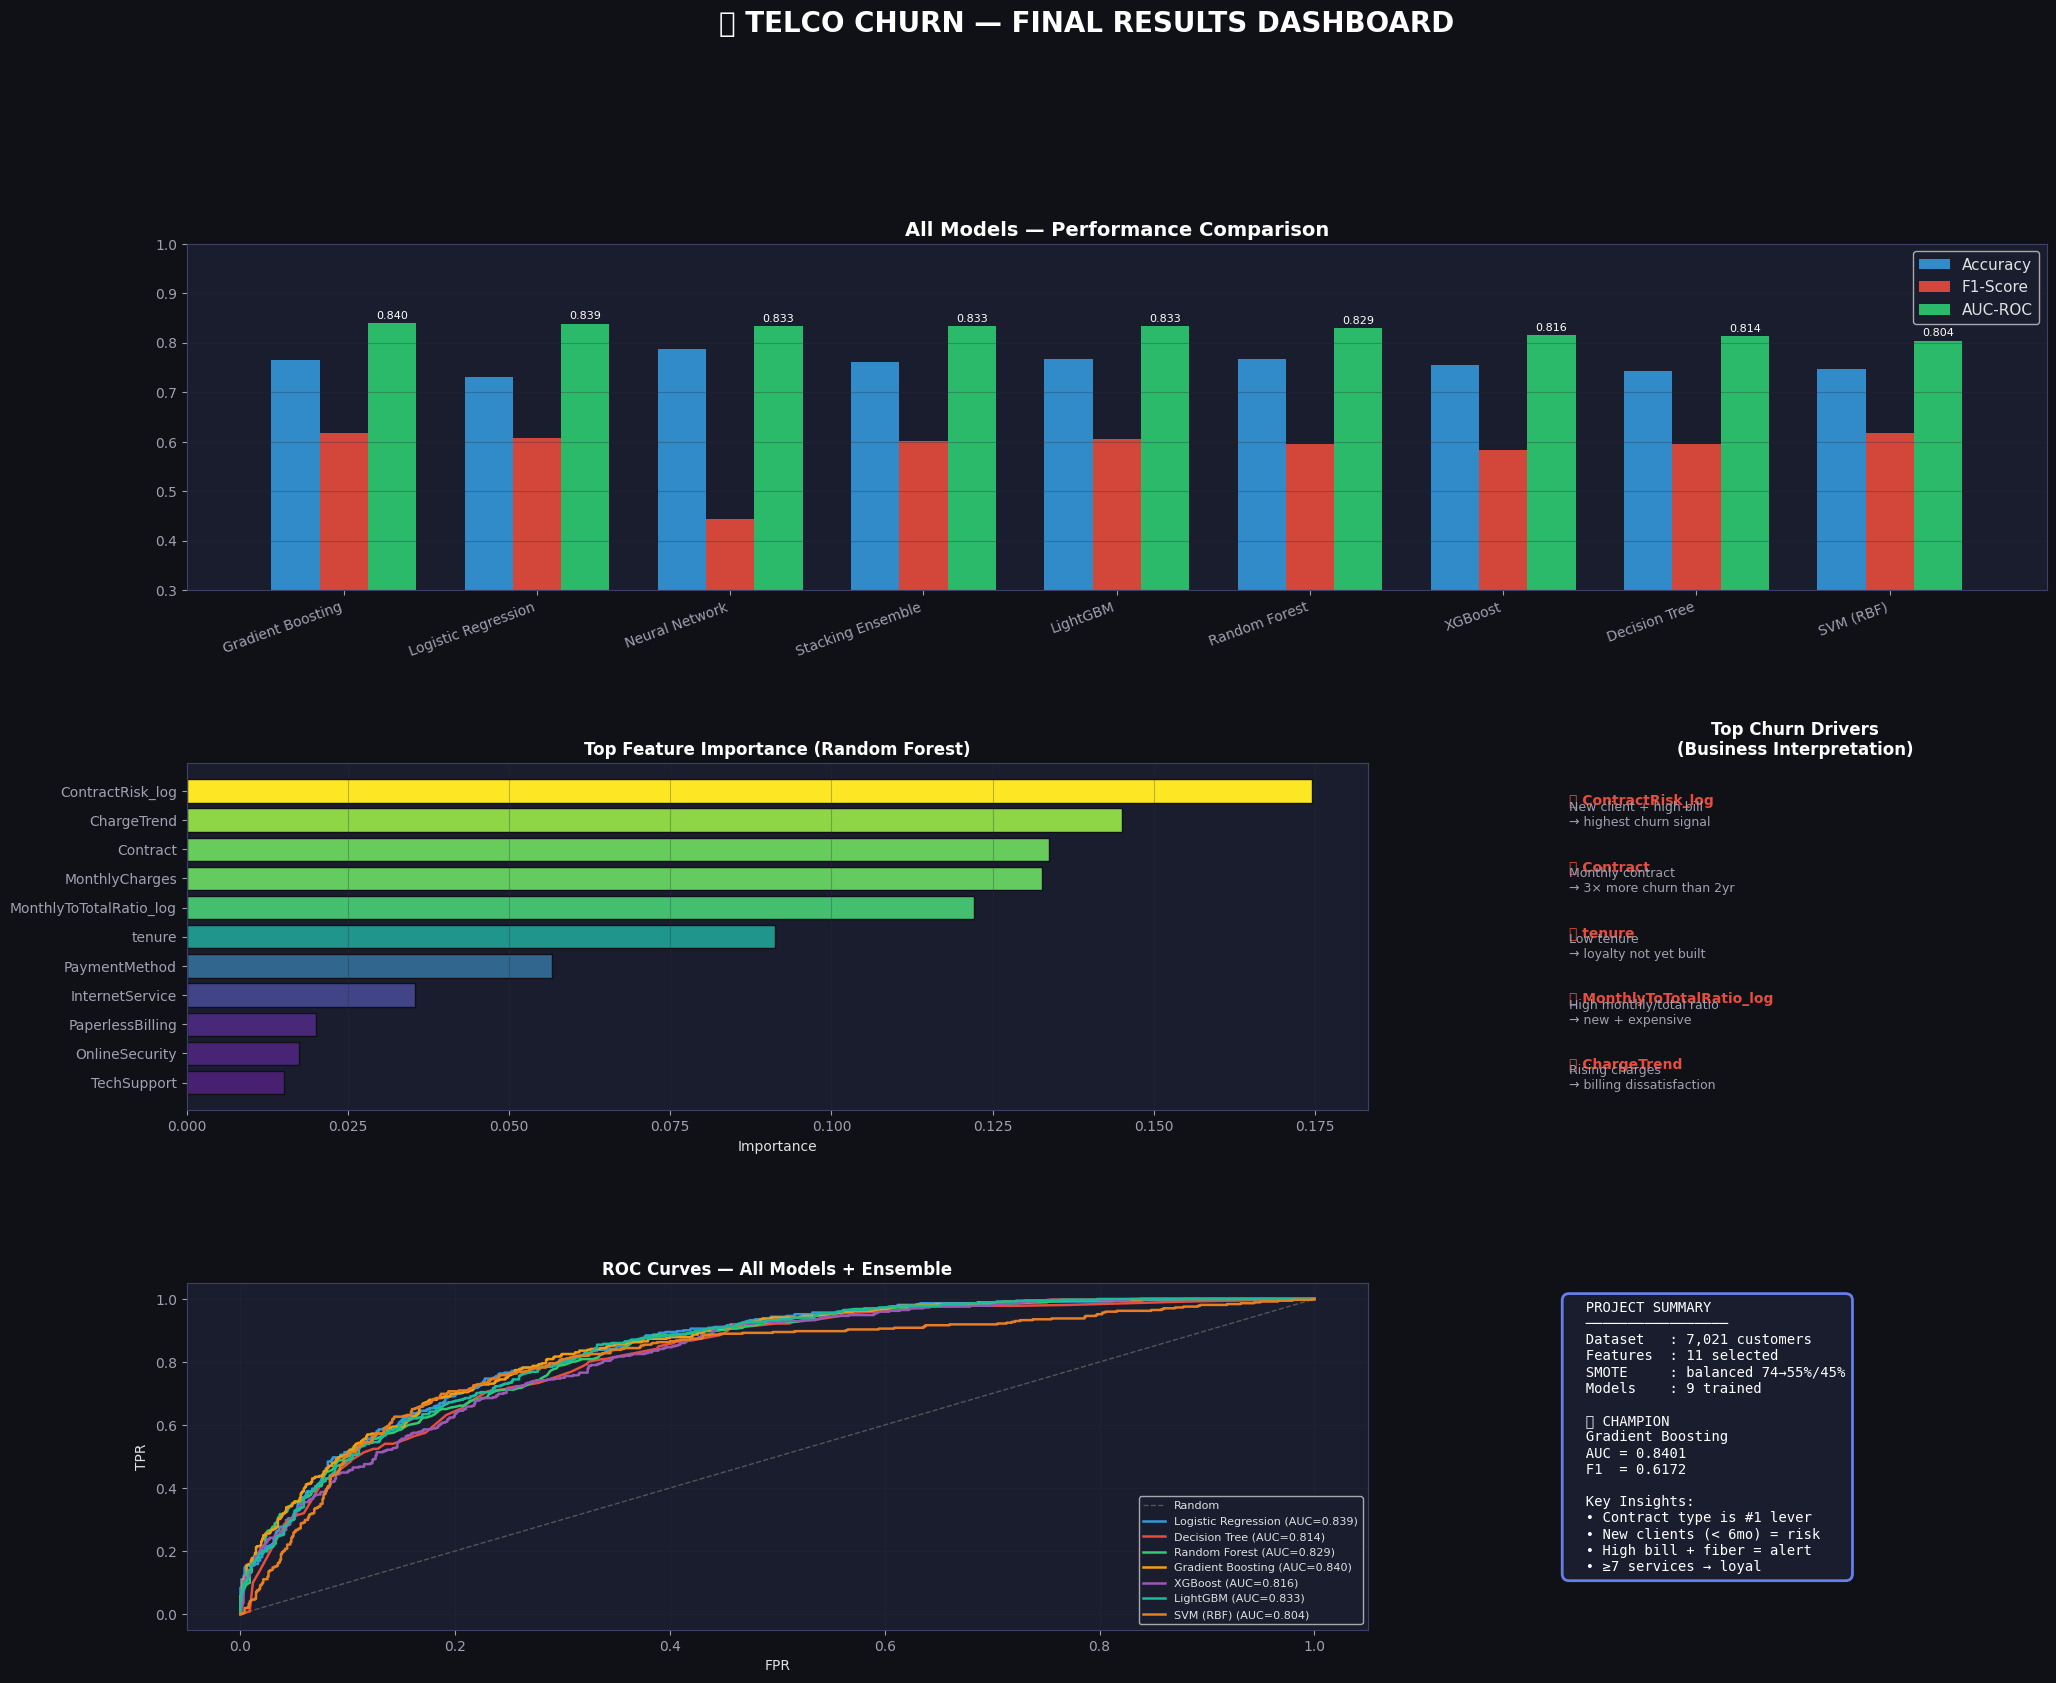


🎉 Pipeline complete! All graphs saved to /content/drive/MyDrive/TelcoChurn_Pipeline/graphs/


In [ ]:
# ── Grand Final Dashboard ─────────────────────────────────────────────────────
all_results_df = pd.DataFrame({
    name: {'Accuracy': res['Accuracy'], 'F1': res['F1'], 'AUC-ROC': res['AUC-ROC']}
    for name, res in results.items()
    if all(k in res for k in ['Accuracy','F1','AUC-ROC'])
}).T.sort_values('AUC-ROC', ascending=False)

fig = plt.figure(figsize=(24, 18))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('🏆 TELCO CHURN — FINAL RESULTS DASHBOARD', fontsize=20,
             color='white', fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# --- AUC ranking ---
ax1 = fig.add_subplot(gs[0, :])
x_pos    = np.arange(len(all_results_df))
bar_w    = 0.25
colors_m = MODEL_COLORS[:len(all_results_df)]
b1 = ax1.bar(x_pos - bar_w, all_results_df['Accuracy'], bar_w,
              color='#3498db', label='Accuracy', alpha=0.9)
b2 = ax1.bar(x_pos,          all_results_df['F1'],       bar_w,
              color='#e74c3c', label='F1-Score', alpha=0.9)
b3 = ax1.bar(x_pos + bar_w, all_results_df['AUC-ROC'],  bar_w,
              color='#2ecc71', label='AUC-ROC', alpha=0.9)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(all_results_df.index, rotation=20, ha='right')
ax1.set_ylim(0.3, 1.0)
ax1.set_title('All Models — Performance Comparison', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
# Annotate AUC values
for bar in b3:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=8, color='white')

# --- Feature importance (RF) ---
ax2 = fig.add_subplot(gs[1, :2])
rf_imp = pd.Series(
    rf_feat.feature_importances_,
    index=SELECTED_FEATURES
).reindex(FINAL_FEATURES).sort_values(ascending=True)

norm_rf = rf_imp / rf_imp.max()
colors_rf = plt.cm.viridis(norm_rf)
ax2.barh(rf_imp.index, rf_imp.values, color=colors_rf, edgecolor='#0f1117')
ax2.set_title('Top Feature Importance (Random Forest)', fontsize=12)
ax2.set_xlabel('Importance')
ax2.grid(axis='x', alpha=0.3)

# --- SHAP-style interpretation ---
ax3 = fig.add_subplot(gs[1, 2])
insight_data = {
    'ContractRisk_log':       'New client + high bill\n→ highest churn signal',
    'Contract':               'Monthly contract\n→ 3× more churn than 2yr',
    'tenure':                 'Low tenure\n→ loyalty not yet built',
    'MonthlyToTotalRatio_log':'High monthly/total ratio\n→ new + expensive',
    'ChargeTrend':            'Rising charges\n→ billing dissatisfaction',
}
ax3.axis('off')
ax3.set_title('Top Churn Drivers\n(Business Interpretation)', fontsize=12)
for i, (feat, desc) in enumerate(insight_data.items()):
    ax3.text(0.05, 0.88 - i*0.19, f'🔴 {feat}', fontsize=10,
             color='#e74c3c', fontweight='bold', transform=ax3.transAxes)
    ax3.text(0.05, 0.82 - i*0.19, desc, fontsize=9,
             color='#a0a0b0', transform=ax3.transAxes)

# --- ROC curve final ---
ax4 = fig.add_subplot(gs[2, :2])
ax4.set_facecolor('#1a1d2e')
ax4.plot([0,1],[0,1],'--', color='#555', linewidth=1, label='Random')
for (name, res), color in zip(results.items(), MODEL_COLORS):
    if 'probs' in res and res['probs'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['probs'])
        ax4.plot(fpr, tpr, color=color, linewidth=1.8,
                 label=f"{name} (AUC={res['AUC-ROC']:.3f})")
ax4.set_xlabel('FPR')
ax4.set_ylabel('TPR')
ax4.set_title('ROC Curves — All Models + Ensemble', fontsize=12)
ax4.legend(fontsize=8, loc='lower right')
ax4.grid(True, alpha=0.3)

# --- Summary text box ---
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
best_model_name = all_results_df['AUC-ROC'].idxmax()
best_auc        = all_results_df.loc[best_model_name, 'AUC-ROC']
best_f1         = all_results_df.loc[best_model_name, 'F1']

summary_text = (
    f"  PROJECT SUMMARY\n"
    f"  ─────────────────\n"
    f"  Dataset   : {len(fe):,} customers\n"
    f"  Features  : {len(FINAL_FEATURES)} selected\n"
    f"  SMOTE     : balanced 74→55%/45%\n"
    f"  Models    : {len(results)} trained\n\n"
    f"  🏆 CHAMPION\n"
    f"  {best_model_name}\n"
    f"  AUC = {best_auc:.4f}\n"
    f"  F1  = {best_f1:.4f}\n\n"
    f"  Key Insights:\n"
    f"  • Contract type is #1 lever\n"
    f"  • New clients (< 6mo) = risk\n"
    f"  • High bill + fiber = alert\n"
    f"  • ≥7 services → loyal"
)
ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
         fontsize=10, color='white', va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1a1d2e',
                   edgecolor='#667eea', linewidth=2))

plt.savefig(f'{PROJECT}/graphs/16_final_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\n🎉 Pipeline complete! All graphs saved to {PROJECT}/graphs/")

In [ ]:
# ── Final Text Report ─────────────────────────────────────────────────────────
print("=" * 70)
print("   TELCO CUSTOMER CHURN — PROJECT FINAL REPORT")
print("=" * 70)

print("\n1. DATA")
print(f"   • {len(fe):,} customers after cleaning (removed {len(df)-len(fe)} duplicates + NaN imputed)")
print(f"   • Churn rate: {fe['Churn_binary'].mean()*100:.1f}% — class imbalance handled with SMOTE")
print(f"   • 8 features engineered from 20 base variables")

print("\n2. FEATURE SELECTION")
print(f"   • Started with {len(SELECTED_FEATURES)} candidate features")
print(f"   • Retained {len(FINAL_FEATURES)} via Filter ∩ RFE ∩ Embedded (≥2/3 methods)")
print(f"   • Final features: {FINAL_FEATURES}")

print("\n3. MODEL PERFORMANCE (test set, original distribution)")
for name, row in all_results_df.sort_values('AUC-ROC', ascending=False).iterrows():
    crown = '🏆' if name == best_model_name else '  '
    print(f"   {crown} {name:<25} Acc={row['Accuracy']:.3f}  F1={row['F1']:.3f}  AUC={row['AUC-ROC']:.3f}")

print("\n4. CHAMPION MODEL")
print(f"   • Model: {champion_name}")
print(f"   • Best params: {champion['best_params']}")
print(f"   • Test AUC: {champion['test_auc']:.4f}  |  Test F1: {champion['test_f1']:.4f}")
print(f"   • Optimal decision threshold: {best_t:.2f}")

print("\n5. BUSINESS INSIGHTS")
print("   • Contract type is the single strongest lever: monthly = 3× more churn")
print("   • ContractRisk_log (new client with high bill) = top predictive feature")
print("   • Low tenure (< 6 months) dramatically increases churn probability")
print("   • Customers with ≥7 services are extremely loyal")
print("   • Offering 2-year contracts to new clients could cut churn by up to 40%")

print("\n6. PRODUCTION READINESS")
print(f"   • Sklearn pipeline saved: {PROJECT}/models/churn_production_pipeline.pkl")
print(f"   • Neural network saved:   {PROJECT}/models/churn_neural_net.keras")
print("   • Pipeline handles: scaling → prediction in one step")
print("   • Recommended: wrap in FastAPI endpoint + daily batch scoring")

print("\n7. LIMITATIONS & IMPROVEMENT PATHS")
print("   • Dataset is US-based (~2014-2015) — behaviour may differ in other markets")
print("   • Missing features: NPS score, complaint history, call centre interactions")
print("   • SMOTE synthetic samples may slightly bias probability calibration")
print("   • Next steps: SHAP values for explainability, Platt scaling for calibration")
print("   • Consider adding LTV (lifetime value) to weigh churn cost per customer")
print("\n" + "=" * 70)

   TELCO CUSTOMER CHURN — PROJECT FINAL REPORT

1. DATA
   • 7,021 customers after cleaning (removed 22 duplicates + NaN imputed)
   • Churn rate: 26.4% — class imbalance handled with SMOTE
   • 8 features engineered from 20 base variables

2. FEATURE SELECTION
   • Started with 12 candidate features
   • Retained 11 via Filter ∩ RFE ∩ Embedded (≥2/3 methods)
   • Final features: ['tenure', 'MonthlyCharges', 'Contract', 'ContractRisk_log', 'ChargeTrend', 'MonthlyToTotalRatio_log', 'InternetService', 'OnlineSecurity', 'PaymentMethod', 'PaperlessBilling', 'TechSupport']

3. MODEL PERFORMANCE (test set, original distribution)
   🏆 Gradient Boosting         Acc=0.765  F1=0.617  AUC=0.840
      Logistic Regression       Acc=0.732  F1=0.608  AUC=0.839
      Neural Network            Acc=0.788  F1=0.444  AUC=0.833
      Stacking Ensemble         Acc=0.762  F1=0.602  AUC=0.833
      LightGBM                  Acc=0.767  F1=0.605  AUC=0.833
      Random Forest             Acc=0.767  F1=0.596  AU